## Gruve AI Engineering Assignment: Diabetes Hospital Readmission Prediction
This notebook addresses the problem of predicting 30-day hospital readmission for diabetic patients using the UCI Diabetes 130-US Hospitals dataset (101,766 encounters).

---

### Table of Contents
- [0. Set-up](#0.-Set-up)
- [1. Data Loading and Preprocessing](#1.-Data-loading-and-preprocessing)
- [2. Split Train & Test & Unseen](#2.-Split-Train-&-Test-&-Unseen)
- [2. Exploratory Data Analysis (EDA)](#2.-Exploratory-Data-Analysis-(EDA))
- [3. Machine Learning Training with AutoGluon](#3.-Machine-Learning-Training-with-AutoGluon)

## 0. Set-up


---

In [ ]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy scikit-learn autogluon imbalanced-learn shap umap-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [13]:
# Imports 
import os
import re
import shutil
import umap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import textwrap
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, chi2 as sklearn_chi2
from scipy.stats import kruskal, chi2_contingency
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTENC
from autogluon.tabular import TabularPredictor
import shap

In [14]:
# Configuration 
DATA_PATH    = '/Users/sieunpark/Desktop/Questions_SQL/diabetic_data.csv'
MAPPING_PATH = '/Users/sieunpark/Desktop/Questions_SQL/IDS_mapping.csv'
UNSEEN_PATH  = '/Users/sieunpark/Desktop/Questions_SQL/unseen_data.csv'
MODEL_PATH   = 'ag_models/'

RANDOM_STATE = 42 # For reproducibility
TEST_SIZE    = 0.20   # 80/20 train/test split
UNSEEN_SIZE  = 0.05   # 5% held out as unseen

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Chart colours 
BLUE   = '#4472C4'   # blue
ORANGE = '#ED7D31'   # orange
GREEN  = '#A9D18E'   # green
DARK_GREY   = '#333333'  # bar annotation text
TITLE_COLOR  = '#1a1a1a'  # chart title text
AX_BG_COLOR  = '#f7f9fc'  # subplot background

# AutoGluon — GBM models only (memory-efficient, no torch needed)
GBM_ONLY = {
    'GBM': [{}],   # LightGBM
    'XGB': [{}],   # XGBoost
    'CAT': [{}],   # CatBoost
}

# Column groups
NUM_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
]
MED_COLS = [
    'metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
    'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
    'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
    'examide','citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone',
]
CAT_COLS = [
    'race','gender','age','admission_type_id','discharge_disposition_id',
    'admission_source_id','payer_code','medical_specialty',
    'max_glu_serum','A1Cresult','change','diabetesMed',
]

## 1. Data loading and preprocessing
--- 

#### 1.1.  Decode ID Columns
* Loaded the dataset and decoded three ID columns into human-readable labels using IDS_mapping.csv.

In [15]:
df = pd.read_csv(DATA_PATH)

# Decode ID columns using IDS_mapping.csv
# Each section has a header row followed by id → label rows
mapping_raw = pd.read_csv(MAPPING_PATH, header=None, names=['id', 'label'])
ID_COLS = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

current_col = None
mappings    = {}
for _, (id_val, label) in mapping_raw.iterrows():
    if id_val in ID_COLS:
        current_col = id_val
    elif pd.notna(id_val) and current_col:
        mappings.setdefault(current_col, {})[int(id_val)] = label

for col, mapping in mappings.items():
    df[col] = df[col].map(mapping).fillna(df[col])

#### 1.2.  Data Cleaning

##### 1.2.1.  Nulls, Duplicates & Data Types

* Standardised missing values, dropped two zero-variance columns (examide, citoglipton), and removed deceased/hospice patients who cannot be readmitted.

* Fixed data types: age set as ordered categorical, numerical columns coerced to numeric.

In [16]:
# Normalise missing values
null_labels = {'?', 'NULL', 'Not Mapped', 'Not Available', 'Unknown/Invalid'}
df.replace(null_labels, pd.NA, inplace=True)

# Drop zero-variance columns
df.drop(columns=['examide', 'citoglipton'], inplace=True)

# Remove deceased / hospice patients (cannot be readmitted)
exclude_ids = {
    k for k, v in mappings.get('discharge_disposition_id', {}).items()
    if any(kw in str(v) for kw in {'Expired', 'Hospice'})
}
df = df[~df['discharge_disposition_id'].isin(exclude_ids)]

# Fix data types
df['age'] = pd.Categorical(df['age'], ordered=True, categories=[
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
])
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors='coerce')

##### 1.2.2. Fill Missing Values

* Handled missing values per column: max_glu_serum/A1Cresult filled with 'Not Recorded' (clinically meaningful absence), high-missingness columns filled with 'Unknown' or mode, and weight dropped (97% missing).

* Dropped 3 rows with missing gender.

In [17]:
# >80% missing but clinically meaningful 
for col in ['max_glu_serum', 'A1Cresult']:
    df[col] = df[col].fillna('Not Recorded')

# Drop weight — 97% missing, too sparse to carry signal
df.drop(columns='weight', inplace=True)

# High missingness categorical
for col in ['medical_specialty', 'payer_code']:
    df[col] = df[col].fillna('Unknown')

# Race — fill with 'Unknown' 
df['race'] = df['race'].fillna('Unknown')

# ID-mapped columns — fill with mode
for col in ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Diagnosis codes
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('Unknown')

# Drop 3 rows with missing gender 
df.dropna(subset='gender', inplace=True)

## 2. Split Train & Test & Unseen
--- 

* Split by patient_nbr to prevent leakage: 5% held out as unseen, remaining 95% split 80/20 into train and test.

* No patient appears in more than one split.

In [18]:
# Split on patient_nbr so no patient appears in both train and unseen sets

all_patients = df['patient_nbr'].unique()
train_patients, unseen_patients = train_test_split(
    all_patients,
    test_size=UNSEEN_SIZE,
    random_state=RANDOM_STATE,
)

train_df  = df[df['patient_nbr'].isin(train_patients)]
unseen_df = df[df['patient_nbr'].isin(unseen_patients)]

unseen_df.to_csv(UNSEEN_PATH, index=False)

In [19]:
# Split on patient_nbr — no patient leaks across train and test

train_p, test_p = train_test_split(
    train_patients,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

X_train = train_df[train_df['patient_nbr'].isin(train_p)].drop(columns='readmitted')
y_train = train_df[train_df['patient_nbr'].isin(train_p)]['readmitted']
X_test  = train_df[train_df['patient_nbr'].isin(test_p)].drop(columns='readmitted')
y_test  = train_df[train_df['patient_nbr'].isin(test_p)]['readmitted']

#### Evaluation Protocol

| Split | Size | Purpose |
|---|---|---|
| `X_train / y_train` | 80% of 95% | Model training & cross-validation |
| `X_test / y_test` | 20% of 95% | **Final evaluation — reported to graders** |
| `unseen_data.csv` | 5% | Grader holdout — do NOT use |

<br>
`X_test / y_test` is used once only, after all training and tuning is complete, to report final model performance.


### 2. Exploratory Data Analysis (EDA)

---
All analysis is performed exclusively on the **training set** (`X_train / y_train`) to prevent data leakage.

In [20]:
# Working copy of training data with target included
train_eda = X_train.copy()
train_eda['readmitted'] = y_train.values

#### 2.1. Dataset Overview — Shape, Data Types & Memory Usage

In [21]:
print(f'Shape  : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns')
print(f'Memory : {X_train.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print(f'Dtypes :\n{X_train.dtypes.value_counts().to_string()}')

Shape  : 77,439 rows × 46 columns
Memory : 152.18 MB
Dtypes :
object      35
int64       10
category     1


#### 2.2. Missing Value Analysis

In [22]:
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print('No missing values in training set.')
else:
    print(missing.to_frame('count').assign(pct=lambda x: (x['count'] / len(X_train) * 100).round(2)))

No missing values in training set.


#### 2.3. Target Variable Distribution & Class Imbalance

* The training set is imbalanced: NO dominates at 53.8%, >30 at 35.0%, and <30 is the minority at 11.2% (4.8× imbalance ratio).

* SMOTE is applied later to address this before training.

  NO       41,635  (53.8%)
  >30      27,127  (35.0%)
  <30       8,677  (11.2%)
Imbalance ratio: 4.8x


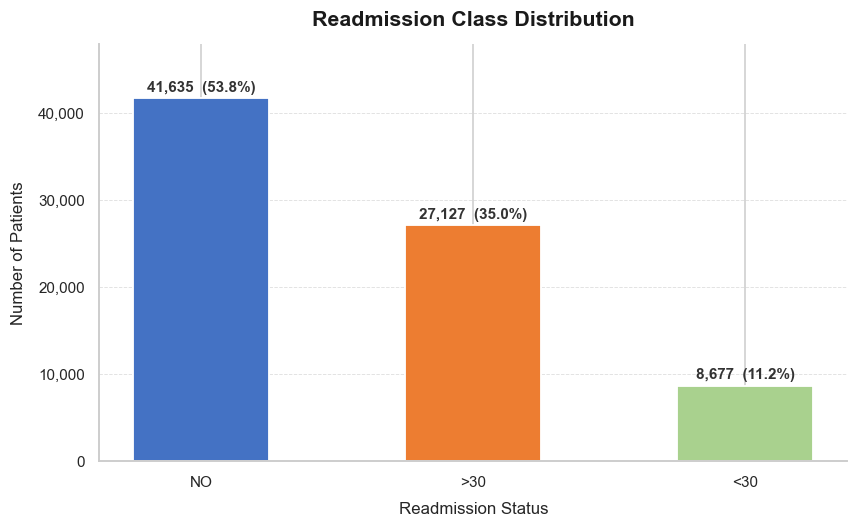

In [23]:
counts = y_train.value_counts()
pcts   = y_train.value_counts(normalize=True) * 100

# Print summary
for cls in counts.index:
    print(f'  {cls:<6}  {counts[cls]:>7,}  ({pcts[cls]:.1f}%)')
print(f'Imbalance ratio: {counts.max() / counts.min():.1f}x')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))

palette = [BLUE, ORANGE, GREEN]
bars = ax.bar(counts.index, counts.values,
              color=palette[:len(counts)], edgecolor="white",
              linewidth=1.2, width=0.5)

# Labels above each bar
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            f"{cnt:,}  ({pct:.1f}%)",
            ha="center", va="bottom",
            fontsize=10, fontweight="bold", color=DARK_GREY)

ax.set_title("Readmission Class Distribution", fontsize=14,
             fontweight="bold", pad=12, color=TITLE_COLOR)
ax.set_xlabel("Readmission Status", fontsize=11, labelpad=8)
ax.set_ylabel("Number of Patients", fontsize=11, labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, counts.max() * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=10)
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


#### 2.4. Descriptive Statistics — Numerical Features

In [24]:
desc = X_train[NUM_COLS].describe().T
desc['skewness'] = X_train[NUM_COLS].skew().round(3)
desc['kurtosis'] = X_train[NUM_COLS].kurt().round(3)
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
time_in_hospital,77439.0,4.396,2.983,1.0,2.0,4.0,6.0,14.0,1.131,0.840
num_lab_procedures,77439.0,43.081,19.673,1.0,31.0,44.0,57.0,132.0,-0.234,-0.249
num_procedures,77439.0,1.341,1.708,0.0,0.0,1.0,2.0,6.0,1.316,0.855
num_medications,77439.0,16.030,8.119,1.0,10.0,15.0,20.0,79.0,1.313,3.390
number_outpatient,77439.0,0.373,1.269,0.0,0.0,0.0,0.0,40.0,8.549,137.357
number_emergency,77439.0,0.198,0.948,0.0,0.0,0.0,0.0,76.0,25.586,1403.048
number_inpatient,77439.0,0.640,1.256,0.0,0.0,0.0,1.0,19.0,3.430,17.993
number_diagnoses,77439.0,7.429,1.927,1.0,6.0,8.0,9.0,16.0,-0.879,-0.083


#### 2.5. Frequency Distributions — Categorical Features
* Plotted lollipop charts for all categorical features 

* Show the top 5 most frequent values as a percentage of the training set

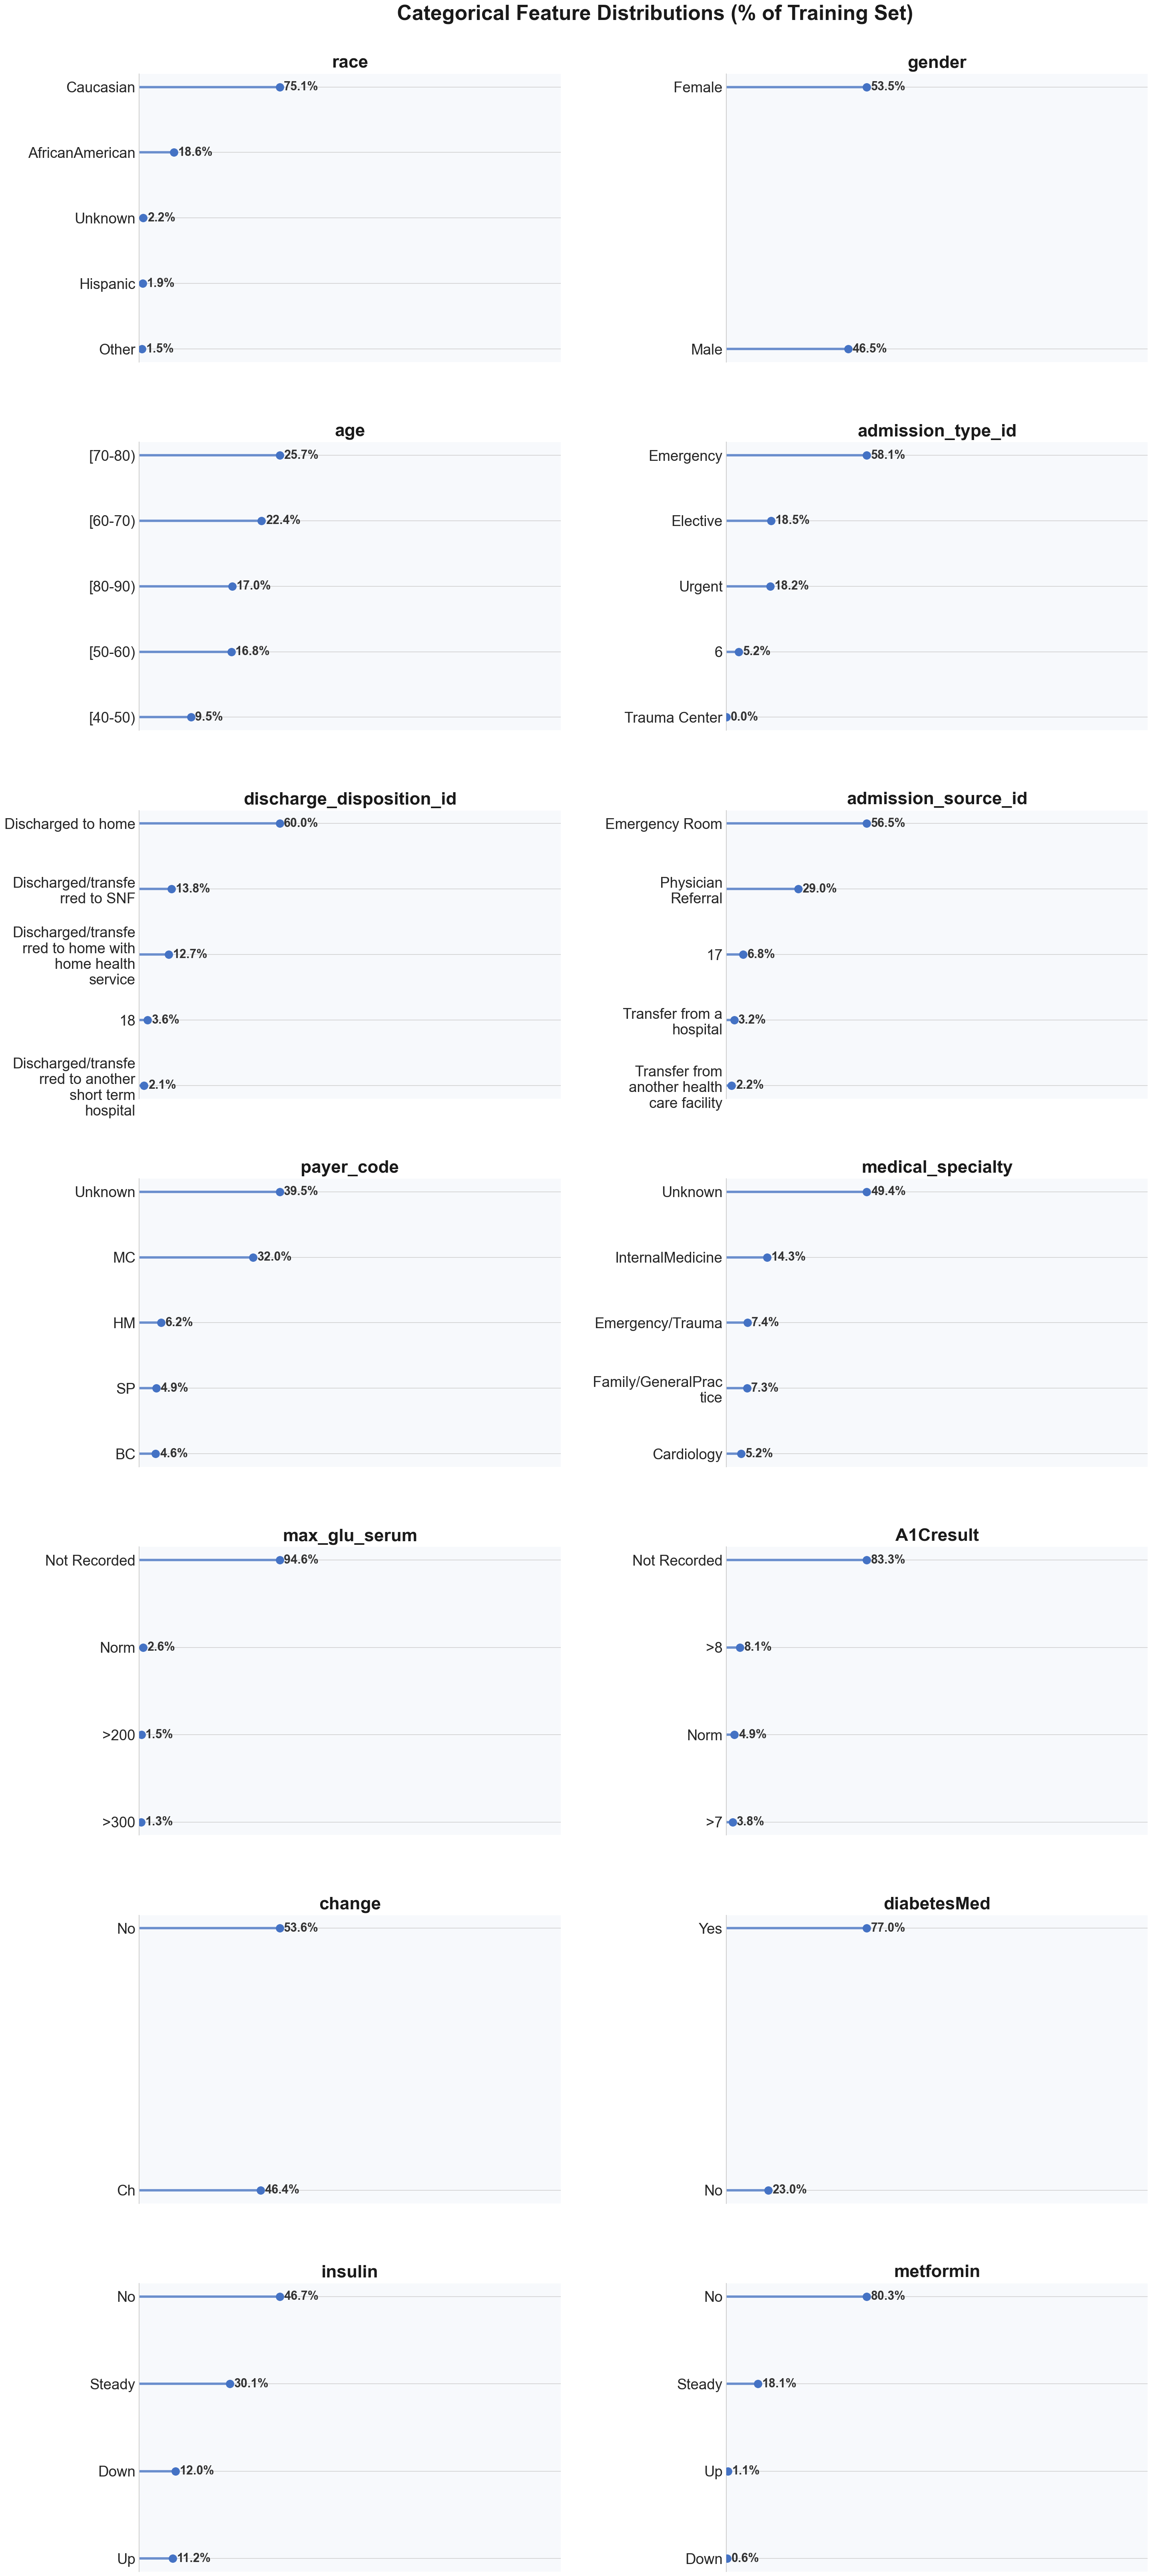

In [25]:
PLOT_CATS = CAT_COLS + ['insulin', 'metformin']

fig, axes = plt.subplots(7, 2, figsize=(30, 62))
axes = axes.flatten()
total = len(X_train)

for i, col in enumerate(PLOT_CATS):
    ax = axes[i]
    vc  = X_train[col].value_counts().head(5).sort_values()
    pct = vc / total * 100
    x_max = pct.values.max()
    labels = [textwrap.fill(str(l), width=18) for l in vc.index]

    ax.hlines(range(len(vc)), xmin=0, xmax=pct.values, color=BLUE, linewidth=4, alpha=0.75)
    ax.scatter(pct.values, range(len(vc)), color=BLUE, s=160, zorder=3)

    for j, val in enumerate(pct.values):
        ax.text(val + x_max * 0.03, j, f'{val:.1f}%',
                va='center', fontsize=20, color=DARK_GREY, fontweight='bold')

    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(labels, fontsize=24)
    ax.set_title(col, fontsize=29, fontweight='bold', pad=10, color=TITLE_COLOR)
    ax.set_xlim(0, x_max * 3.0)
    ax.xaxis.set_visible(False)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.set_facecolor(AX_BG_COLOR)
    ax.tick_params(axis='y', length=0, pad=6)

fig.patch.set_facecolor('white')
plt.suptitle('Categorical Feature Distributions (% of Training Set)',
             fontsize=34, fontweight='bold', y=1.005, color=TITLE_COLOR)
plt.tight_layout(h_pad=5, w_pad=4, rect=[0.0, 0.06, 0.88, 1.0])
plt.show()


#### 2.6. Correlation Analysis — Numerical Features

* Plotted a correlation heatmap for all numerical features.

* No strong correlations (|r| > 0.5) found, but moderate ones exist (e.g. num_medications ↔ time_in_hospital (r = 0.47)).

* Suggests longer stays involve more medications and procedures, but multicollinearity is not a concern.

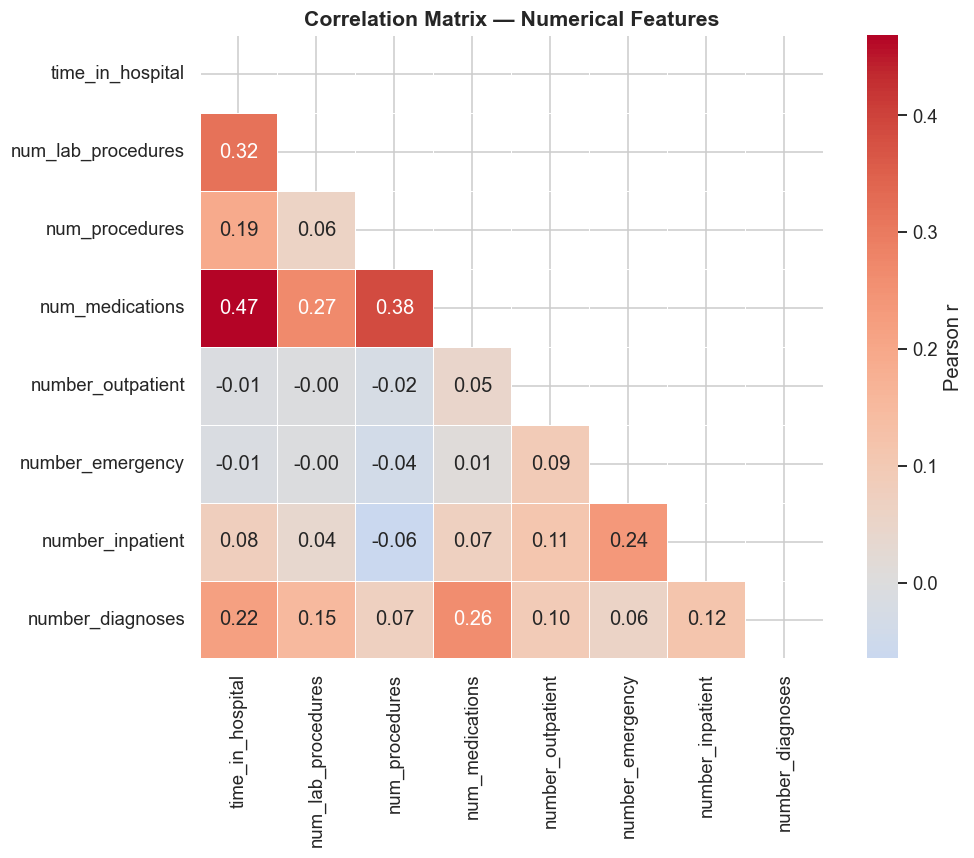

No strong correlations (|r| > 0.5) found.


In [26]:
corr = X_train[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print any strong correlations (|r| > 0.5)
pairs = [(r, c, round(corr.loc[r, c], 3))
         for r in corr.index for c in corr.columns
         if r < c and abs(corr.loc[r, c]) > 0.5]

if pairs:
    print("Strong correlations (|r| > 0.5):")
    for r, c, v in pairs:
        print(f"  {r}  ↔  {c}  :  r = {v}")
else:
    print("No strong correlations (|r| > 0.5) found.")

#### 2.7. Univariate Analysis — Histograms & Box Plots

* Plotted histogram + KDE and box plot for each numerical feature, with skewness and kurtosis annotations.

* Most features are right-skewed, especially number_emergency (skew=24) and number_outpatient (skew=9).

* No outlier removal needed — extreme values are real clinical signals and tree-based models handle skew natively.

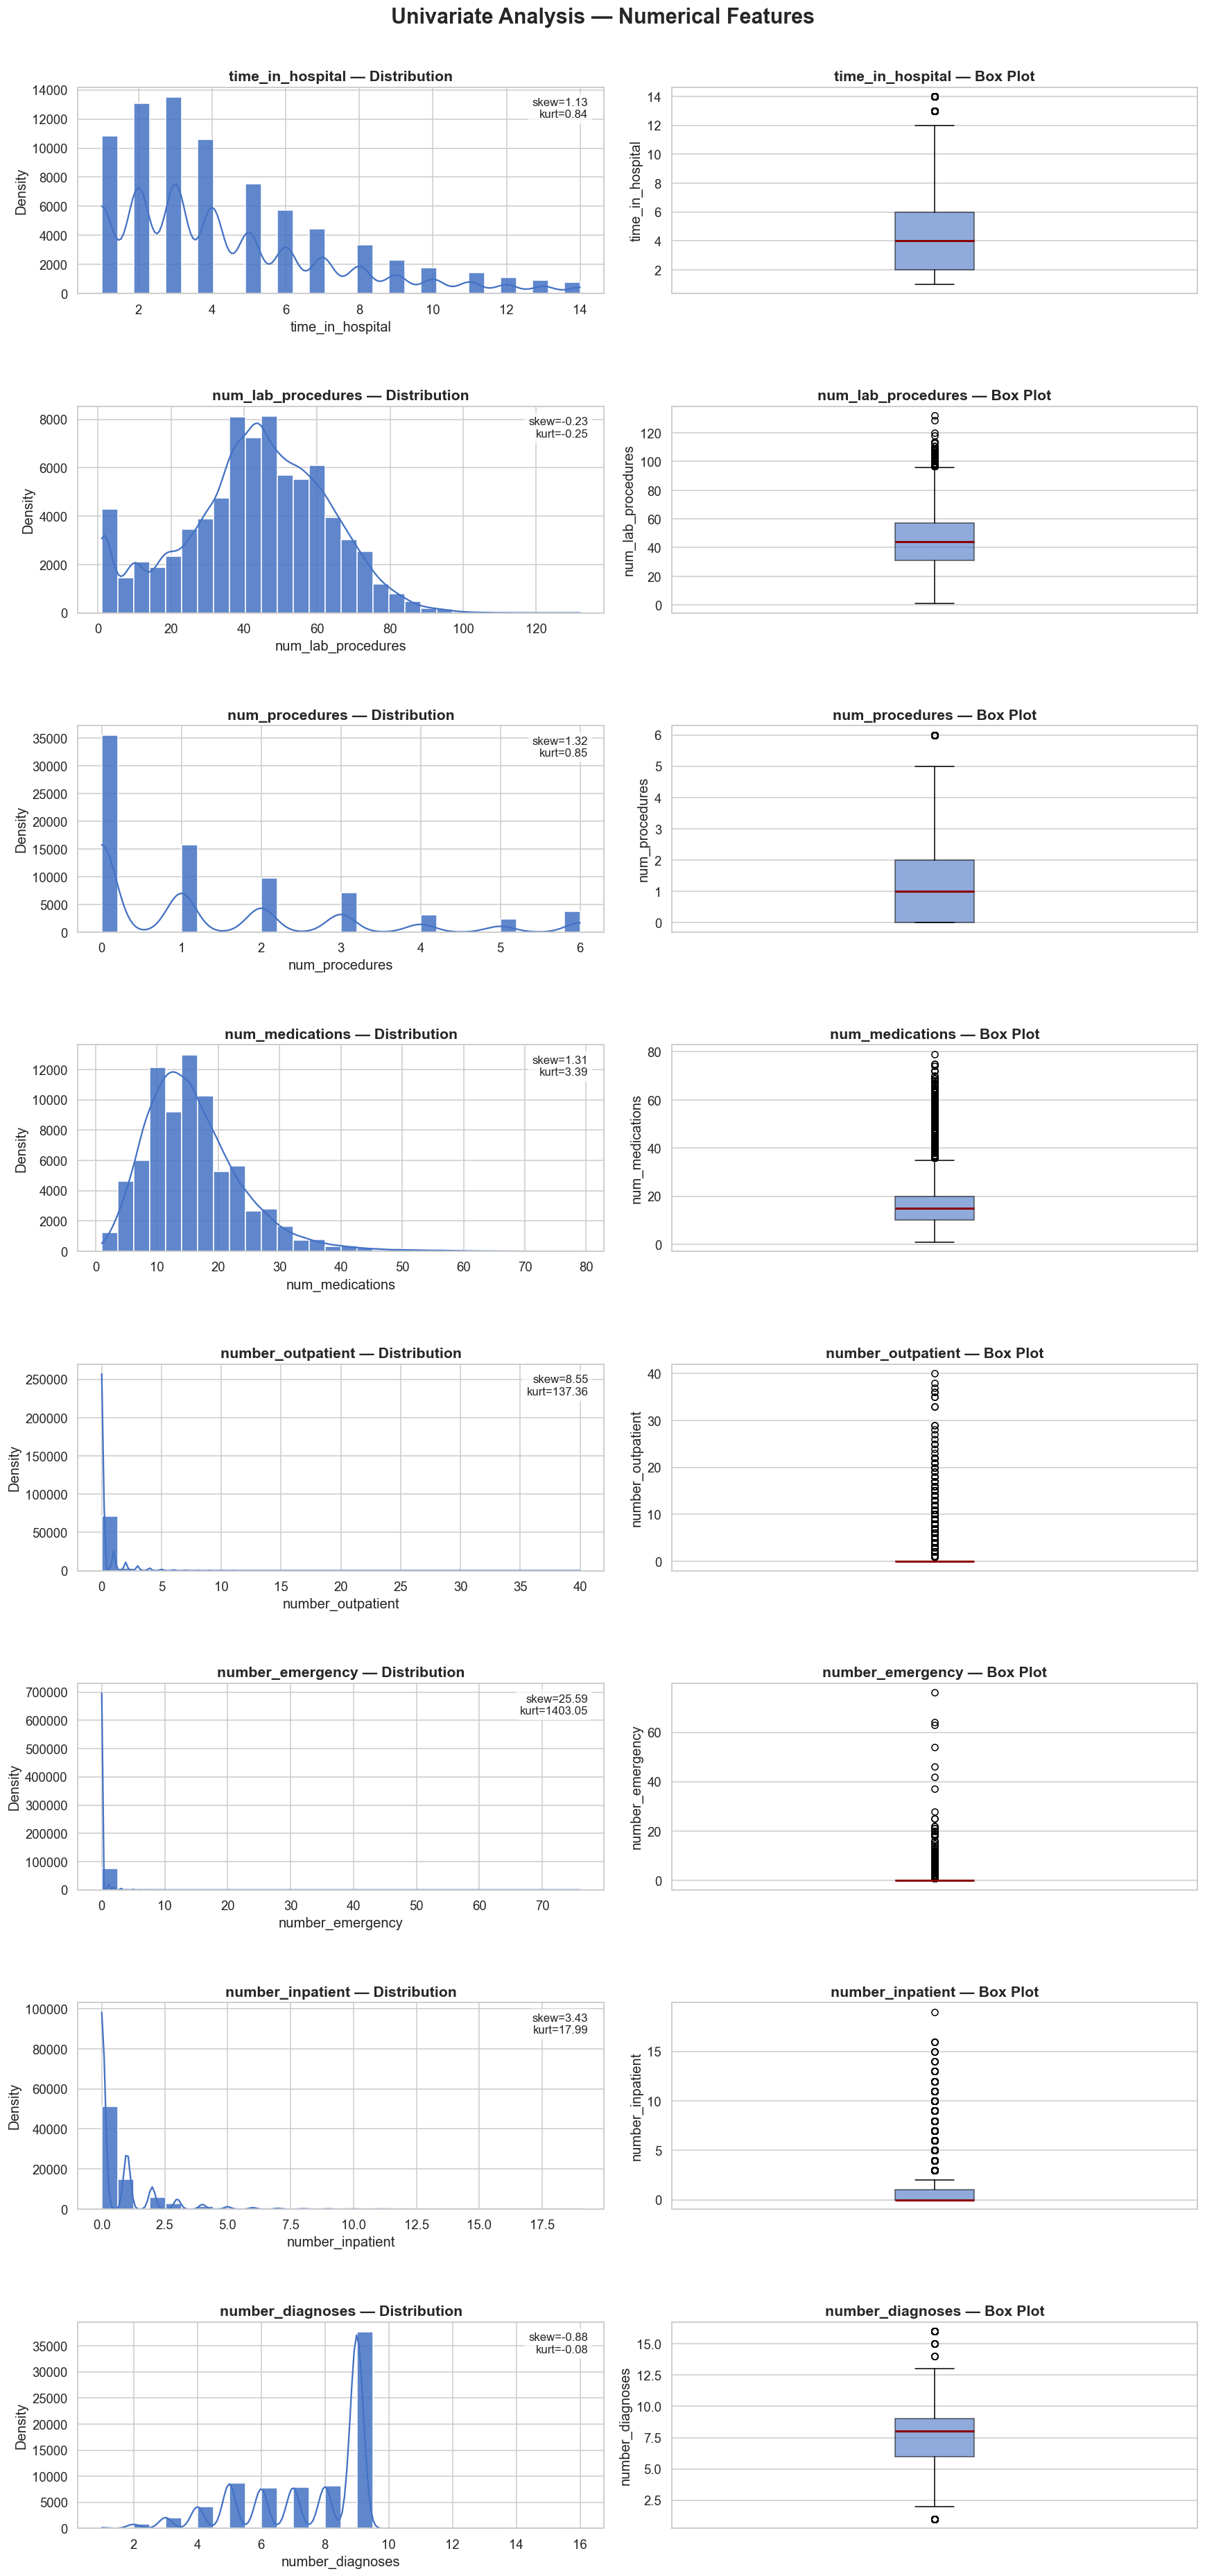

In [27]:
fig, axes = plt.subplots(len(NUM_COLS), 2, figsize=(16, len(NUM_COLS) * 4.2))

for i, col in enumerate(NUM_COLS):
    data = X_train[col].dropna()
    ax0, ax1 = axes[i]

    # Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=ax0, color=BLUE, edgecolor='white', alpha=0.85)
    ax0.set_title(f'{col} — Distribution', fontsize=14, fontweight='bold')
    ax0.set(xlabel=col, ylabel='Density')
    ax0.text(0.97, 0.95, f'skew={data.skew():.2f}\nkurt={data.kurt():.2f}',
             transform=ax0.transAxes, va='top', ha='right', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Box plot
    ax1.boxplot(data, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6),
                medianprops=dict(color='darkred', linewidth=2))
    ax1.set_title(f'{col} — Box Plot', fontsize=14, fontweight='bold')
    ax1.set(ylabel=col)
    ax1.set_xticks([])

plt.suptitle('Univariate Analysis — Numerical Features', fontsize=20, fontweight='bold', y=1.005)
plt.tight_layout(h_pad=4)
plt.show()

#### 2.8. Bivariate Analysis — Feature vs Target (`readmitted`)

* Plotted box plots comparing each numerical feature across the three readmission classes.

* number_inpatient and number_emergency show the clearest separation, with <30 patients having visibly higher prior utilisation.

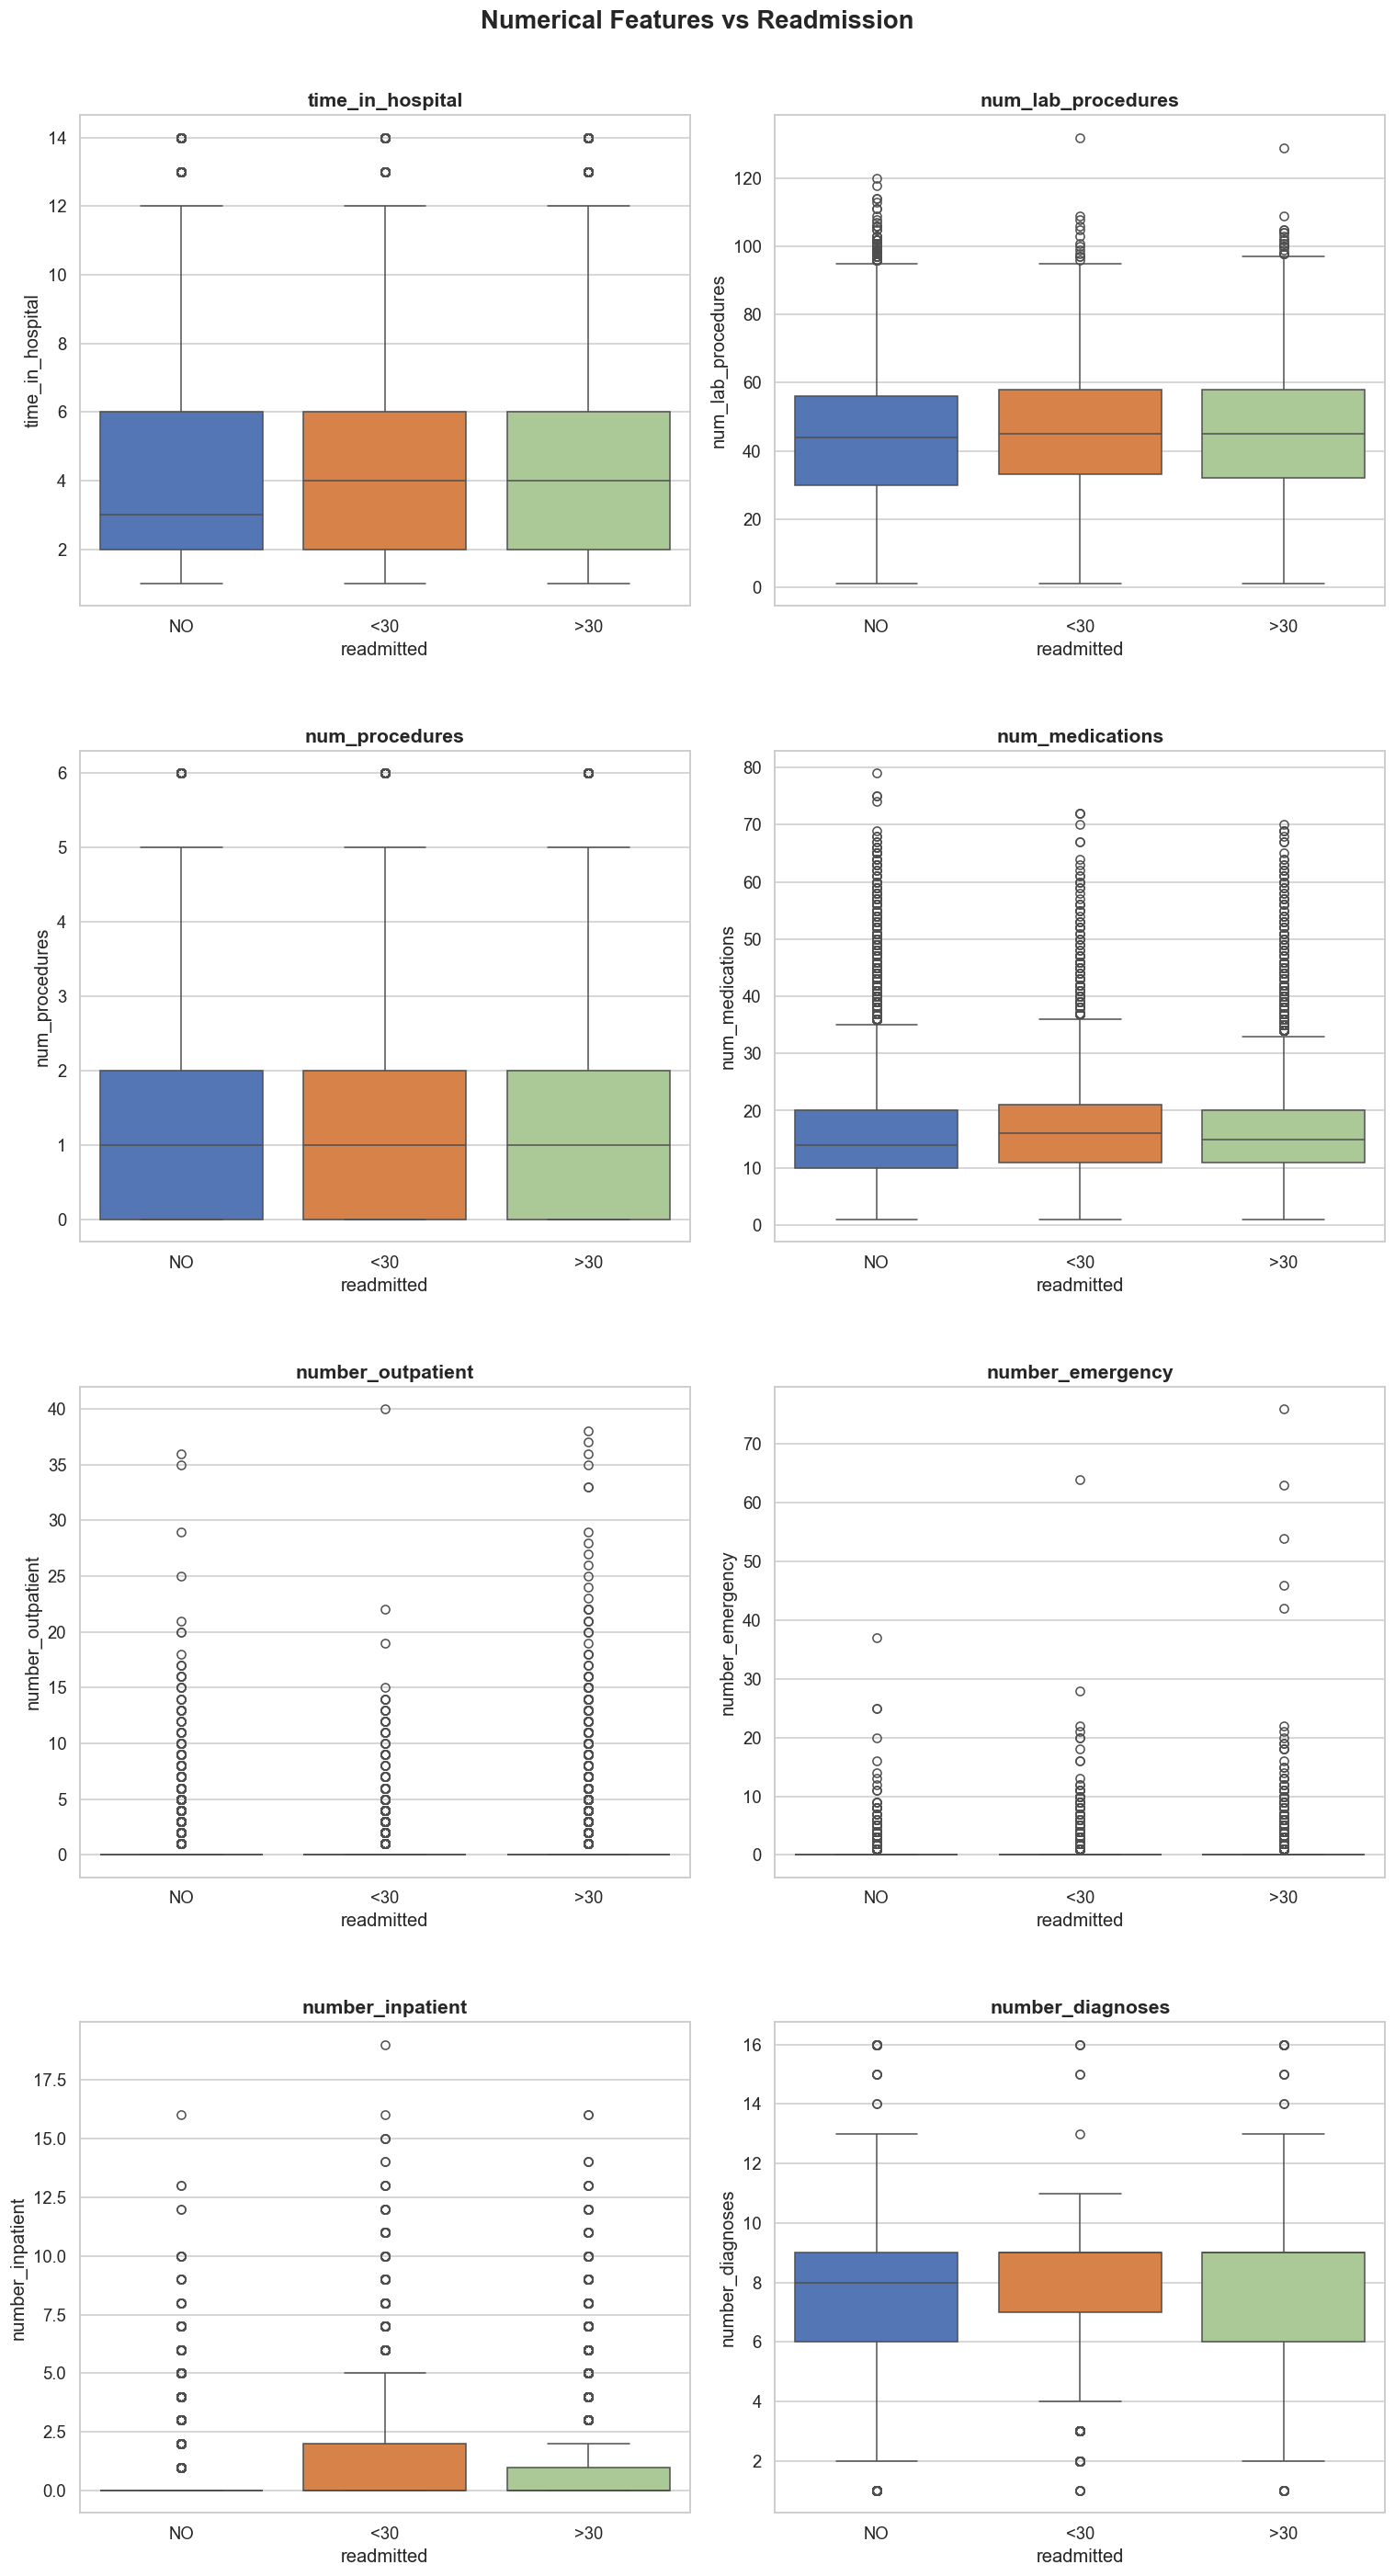

In [28]:
fig, axes = plt.subplots(4, 2, figsize=(14, 26))
axes = axes.flatten()
palette = {'NO': BLUE, '<30': ORANGE, '>30': GREEN}

for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=train_eda, x='readmitted', y=col,
                palette=palette, order=['NO', '<30', '>30'], ax=axes[i])
    axes[i].set_title(col, fontsize=14, fontweight='bold')

plt.suptitle('Numerical Features vs Readmission', fontsize=18, fontweight='bold')
plt.tight_layout(h_pad=4)
plt.subplots_adjust(top=0.94)
plt.show()

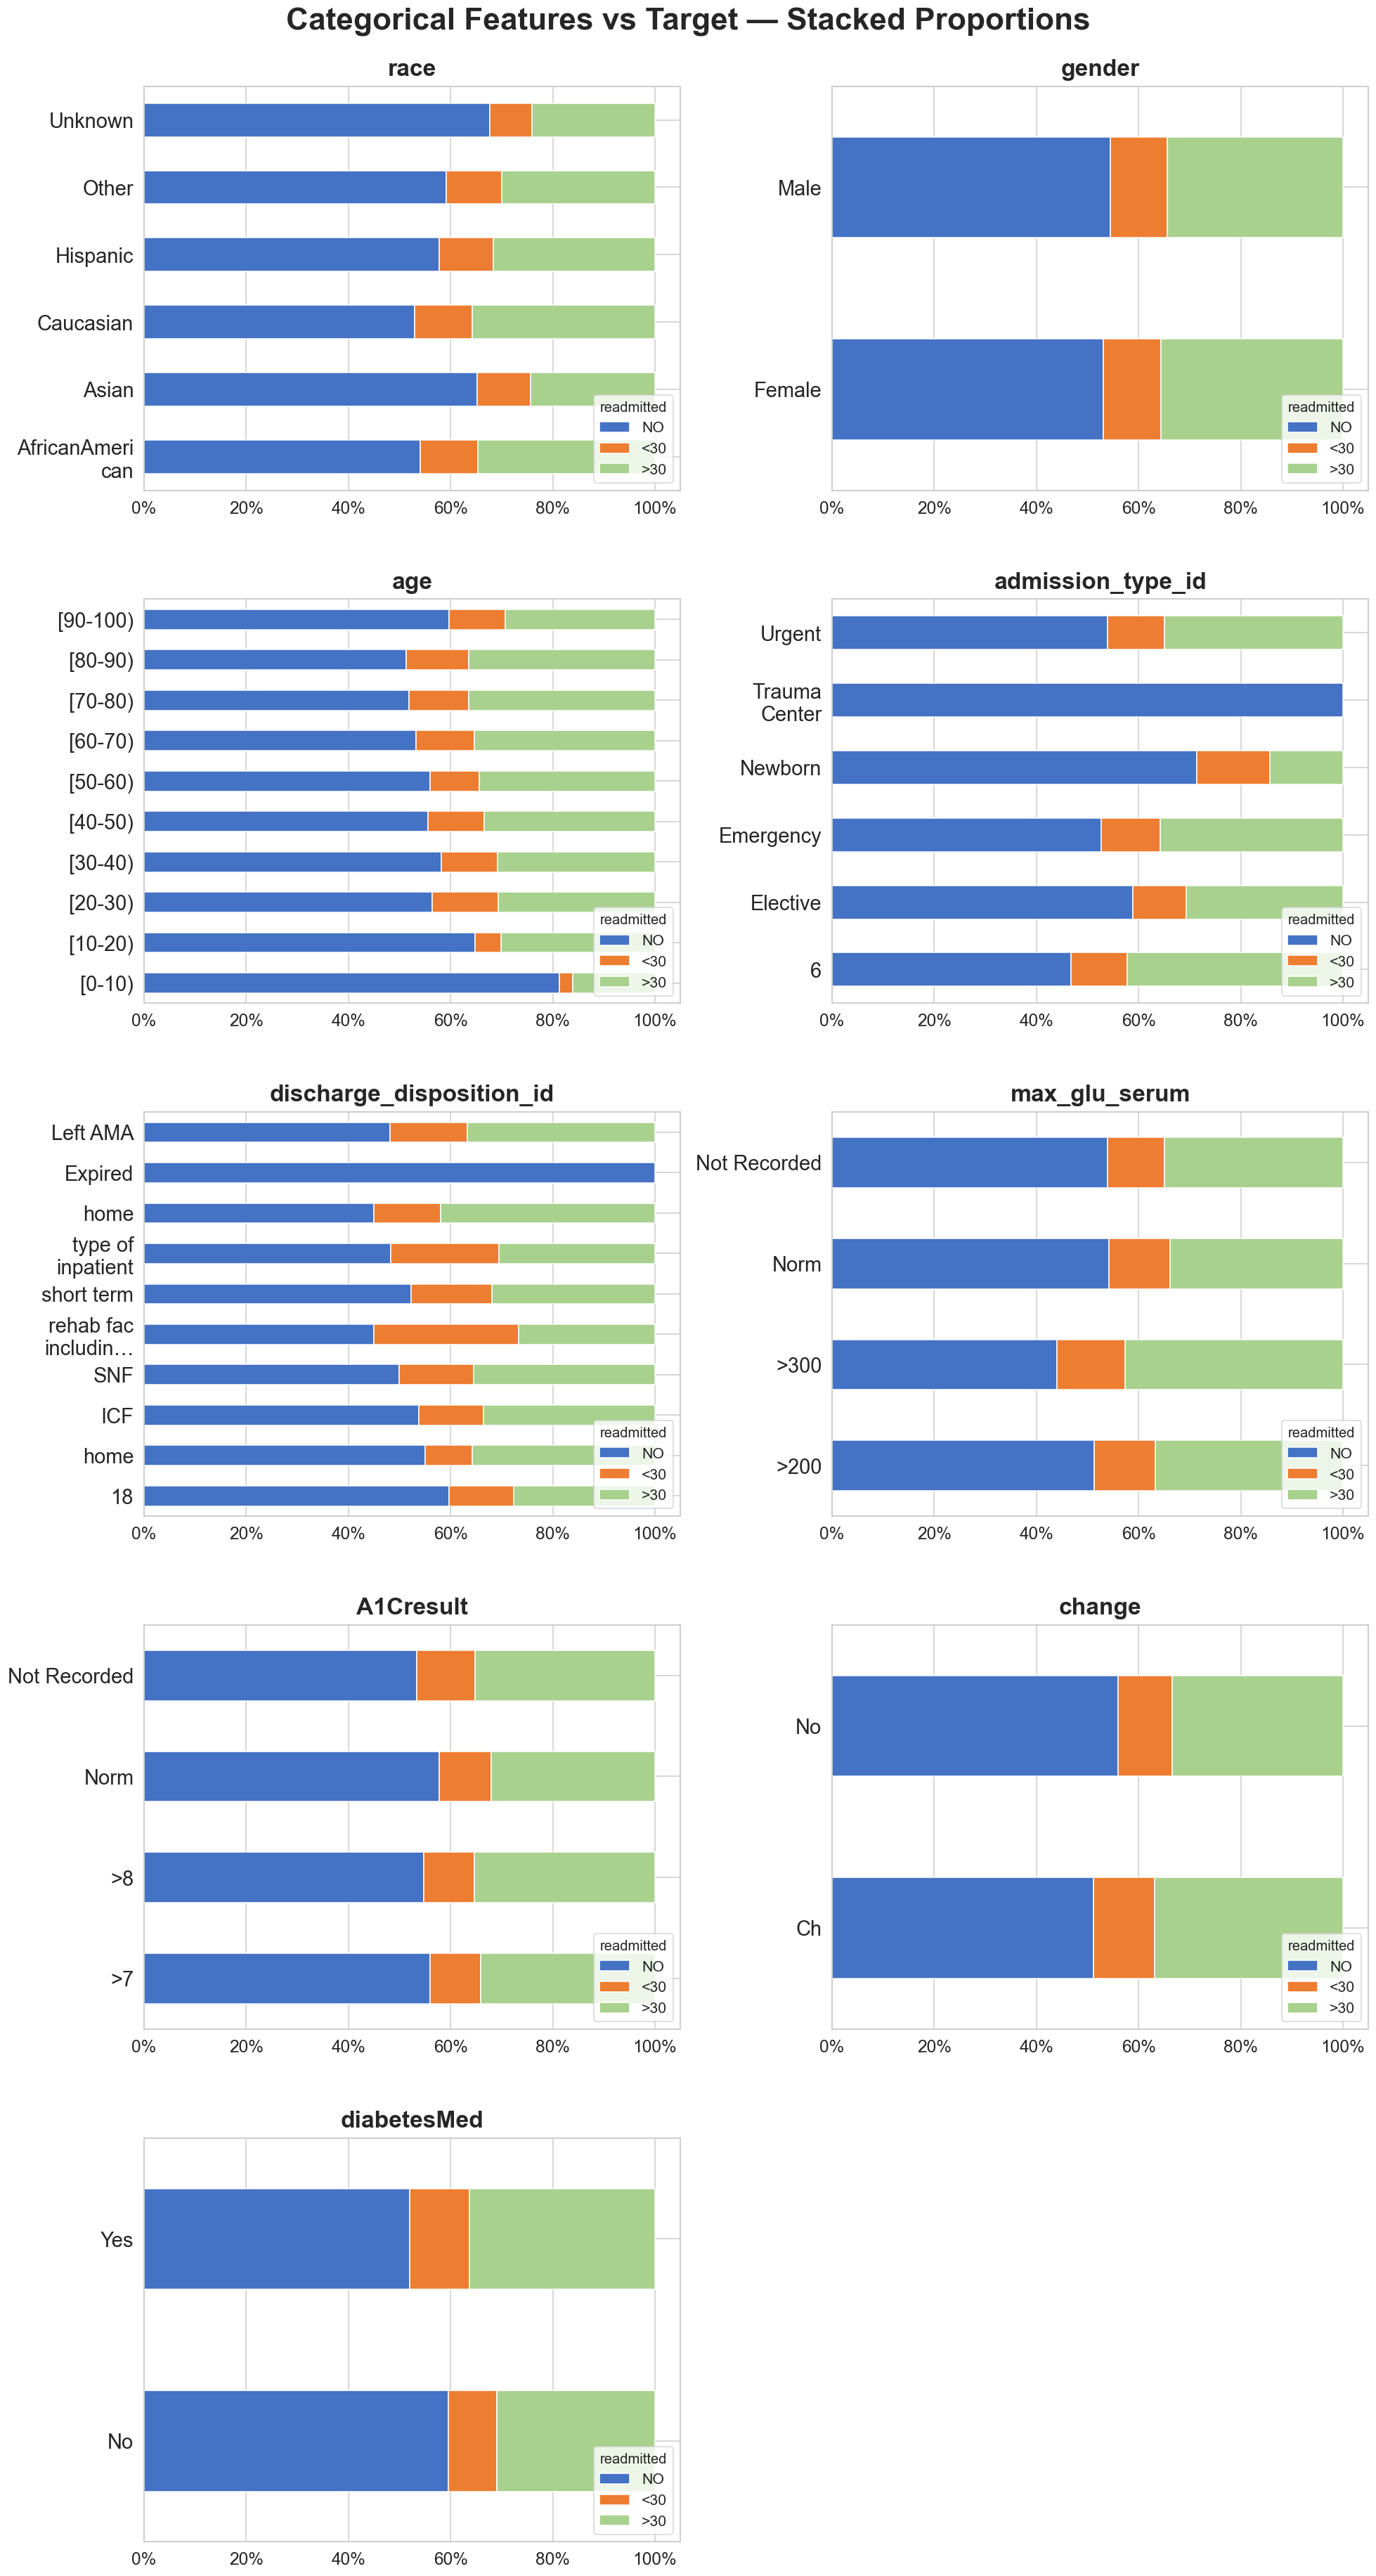

In [29]:
key_cats = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']
order  = ['NO', '<30', '>30']
colors = [BLUE, ORANGE, GREEN]

def shorten_label(text, width=12):
    text = re.sub(r'^Discharged[/\w]*(\s+(to|within|under|as))?\s*', '', str(text)).strip()
    text = re.sub(r'^(another|a |an |this |the |home with )\s*', '', text, flags=re.IGNORECASE).strip()
    text = re.sub(r'\b(care|facility|institution|hospital|service|health)\b', '', text, flags=re.IGNORECASE).strip()
    text = (text[:18] + '\u2026' if len(text) > 18 else text).strip()
    return textwrap.fill(text, width=width)

fig, axes = plt.subplots(5, 2, figsize=(18, 34))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ax  = axes[i]
    top = train_eda[col].value_counts().head(10).index
    ct_pct = (train_eda.groupby([col, 'readmitted'])
                       .size().unstack(fill_value=0)
                       .reindex(columns=order, fill_value=0)
                       .pipe(lambda df: df.div(df.sum(axis=1), axis=0) * 100)
                       .loc[lambda df: df.index.isin(top)])

    ct_pct.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white')
    ax.set_ylabel('')
    ax.set_yticklabels([shorten_label(l) for l in ct_pct.index], fontsize=19)
    ax.set_title(col, fontsize=22, fontweight='bold', pad=10)
    ax.legend(title='readmitted', loc='lower right', fontsize=14)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.tick_params(axis='x', labelsize=16)

axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs Target — Stacked Proportions', fontsize=29, fontweight='bold')
plt.tight_layout(h_pad=4)
plt.subplots_adjust(top=0.95)
plt.show()


#### 2.9. Outlier Detection — IQR & Z-Score Methods
* Detected outliers using IQR (1.5× rule) and Z-score (|z| > 3) methods for each numerical feature.

* number_emergency and number_outpatient had the highest outlier counts, consistent with their heavy right skew.

                        n  IQR outliers  Z-score outliers  IQR %  Z-score %
time_in_hospital    77439          1688               782   2.18       1.01
num_lab_procedures  77439           106                31   0.14       0.04
num_procedures      77439          3794                 0   4.90       0.00
num_medications     77439          1960              1017   2.53       1.31
number_outpatient   77439         12876              1131  16.63       1.46
number_emergency    77439          8702               716  11.24       0.92
number_inpatient    77439          5466              1566   7.06       2.02
number_diagnoses    77439           190               190   0.25       0.25


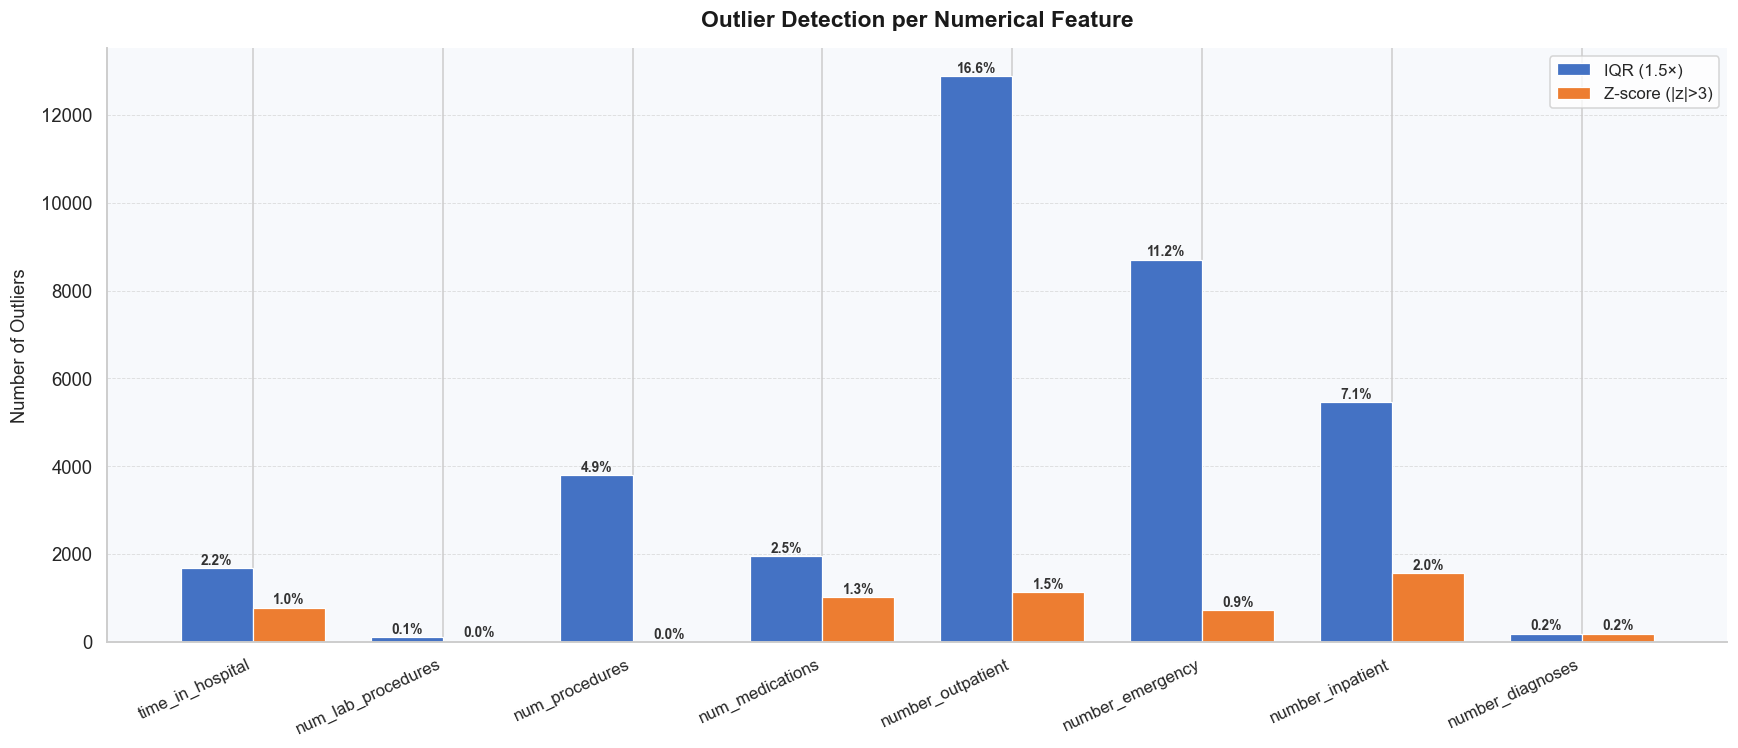

In [30]:
def iqr_outliers(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    return ((s < Q1 - 1.5*(Q3-Q1)) | (s > Q3 + 1.5*(Q3-Q1))).sum()

n   = {c: X_train[c].count() for c in NUM_COLS}
iqr = {c: iqr_outliers(X_train[c].dropna()) for c in NUM_COLS}
zsc = {c: (np.abs(stats.zscore(X_train[c].dropna())) > 3).sum() for c in NUM_COLS}
out_df = pd.DataFrame({'n': n, 'IQR outliers': iqr, 'Z-score outliers': zsc})
out_df['IQR %']     = (out_df['IQR outliers']     / out_df['n'] * 100).round(2)
out_df['Z-score %'] = (out_df['Z-score outliers'] / out_df['n'] * 100).round(2)
print(out_df.to_string())

x, width = np.arange(len(out_df)), 0.38
fig, ax  = plt.subplots(figsize=(16, 7))
ax.set_facecolor(AX_BG_COLOR)

for offset, col, pct_col, color, label in [
    (-width/2, 'IQR outliers',     'IQR %',     BLUE,   'IQR (1.5×)'),
    ( width/2, 'Z-score outliers', 'Z-score %', ORANGE, 'Z-score (|z|>3)'),
]:
    bars = ax.bar(x + offset, out_df[col], width, color=color,
                  label=label, edgecolor='white', linewidth=0.8)
    for bar, pct in zip(bars, out_df[pct_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f'{pct:.1f}%', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=DARK_GREY)

ax.set_xticks(x)
ax.set_xticklabels(out_df.index, rotation=25, ha='right', fontsize=11)
ax.set_ylabel('Number of Outliers', fontsize=12, labelpad=8)
ax.set_title('Outlier Detection per Numerical Feature',
             fontsize=15, fontweight='bold', pad=14, color=TITLE_COLOR)
ax.legend(fontsize=11, framealpha=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#### 2.10. Feature Importance — Mutual Information & Chi-Squared
* Mutual Information ranked number_inpatient, discharge_disposition_id, and number_emergency as the top predictors.

* Chi-Squared confirmed discharge_disposition_id and insulin as the strongest categorical signals against the target.


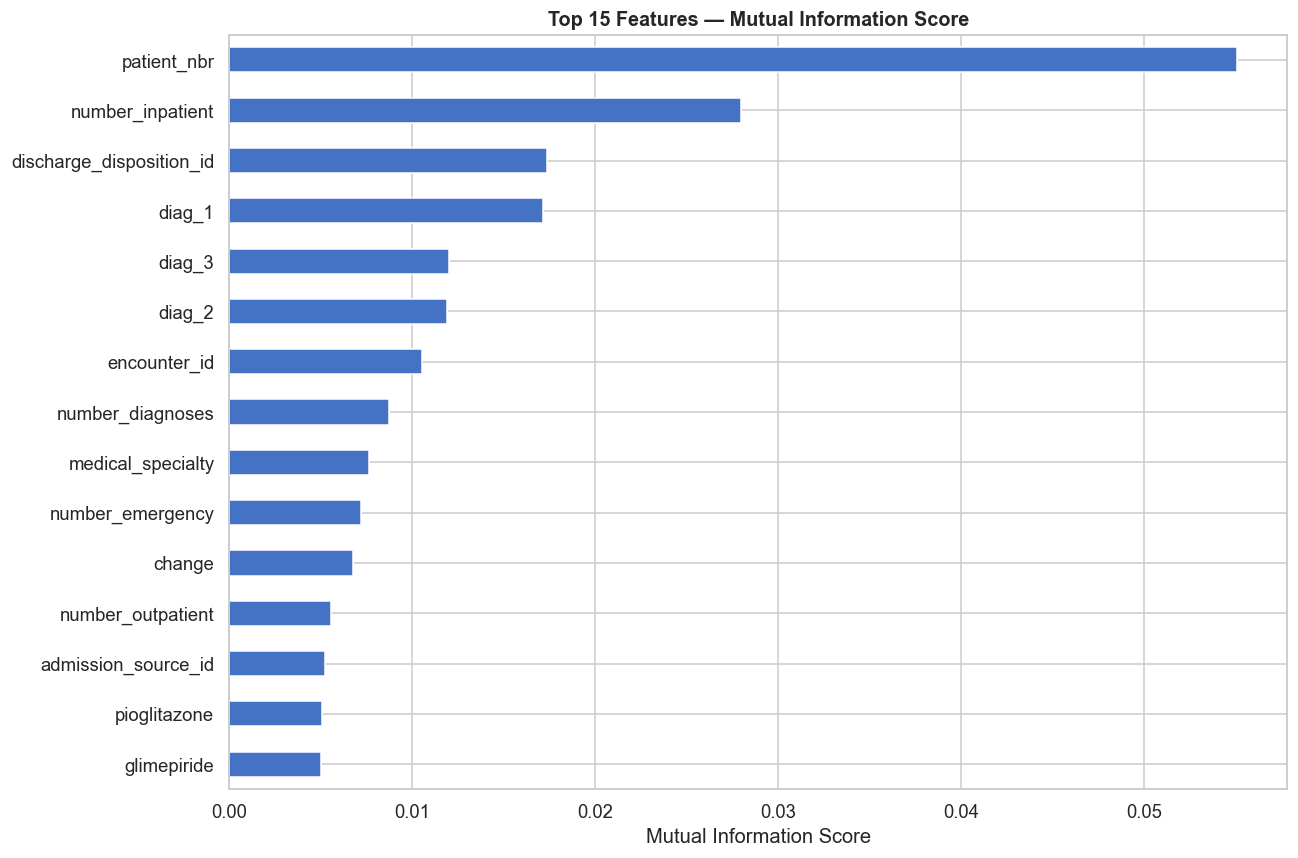

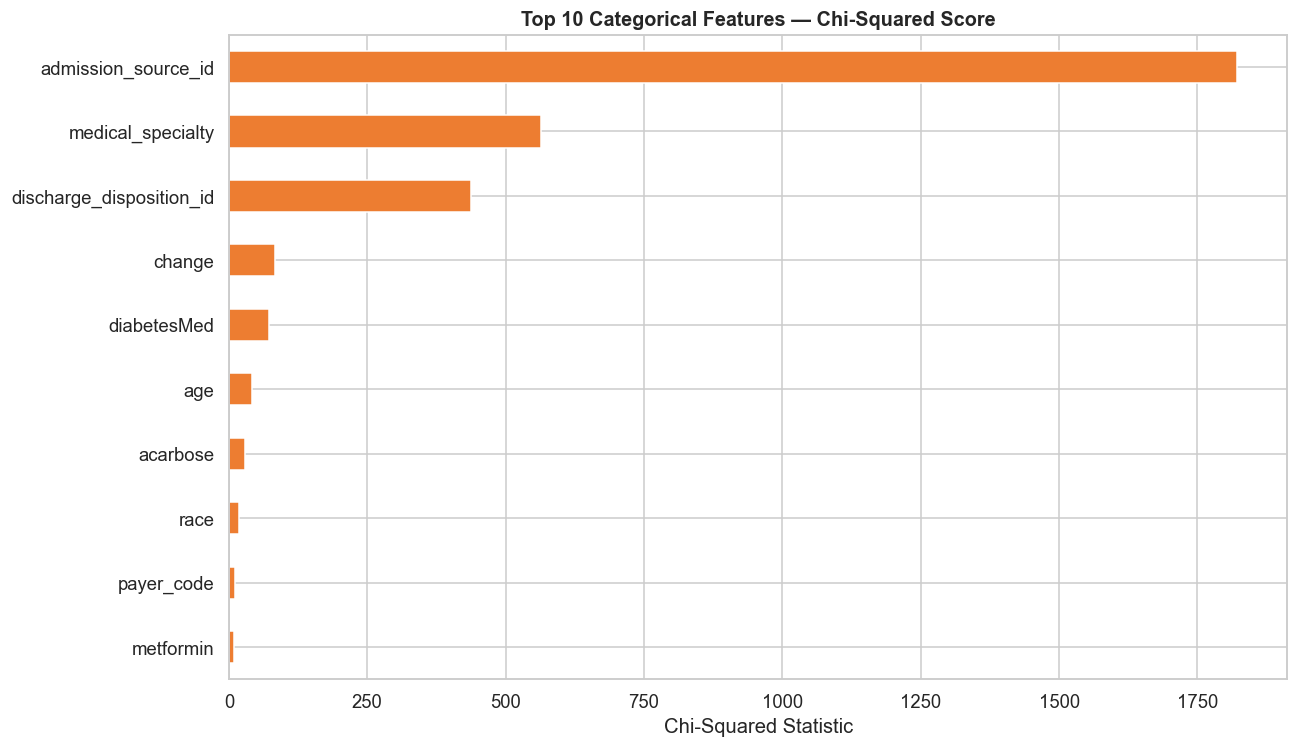

In [31]:
# Encode features as integers for MI and chi-squared scoring
X_enc = train_eda.drop(columns='readmitted').copy()
le = LabelEncoder()
for col in X_enc.select_dtypes(include='object').columns:
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
if hasattr(X_enc['age'], 'cat'):
    X_enc['age'] = X_enc['age'].cat.codes
y_enc = le.fit_transform(train_eda['readmitted'])

# Mutual Information
mi_df = (pd.Series(mutual_info_classif(X_enc, y_enc, random_state=RANDOM_STATE, n_neighbors=5),
                   index=X_enc.columns)
           .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12, 8))
mi_df.head(15).plot(kind='barh', ax=ax, color=BLUE, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 15 Features — Mutual Information Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

# Chi-Squared (categorical + medication features only)
chi_cols = [c for c in CAT_COLS + MED_COLS if c in X_enc.columns]
chi2_scores, _ = sklearn_chi2(X_enc[chi_cols], y_enc)
chi2_df = pd.Series(chi2_scores, index=chi_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
chi2_df.head(10).plot(kind='barh', ax=ax, color=ORANGE, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 Categorical Features — Chi-Squared Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Chi-Squared Statistic')
plt.tight_layout()
plt.show()


#### 2.11. Diagnosis Code Category Analysis (ICD-9)

* Grouped raw ICD-9 diagnosis codes into 14 clinical categories and plotted readmission rates and patient volume per category.

* Circulatory is the dominant diagnosis (23,085 patients), followed by Respiratory and Digestive.

* Blood Disorders (14.8%) and Diabetes (13.4%) have the highest early readmission (<30) rates, suggesting these conditions carry greater acute risk.

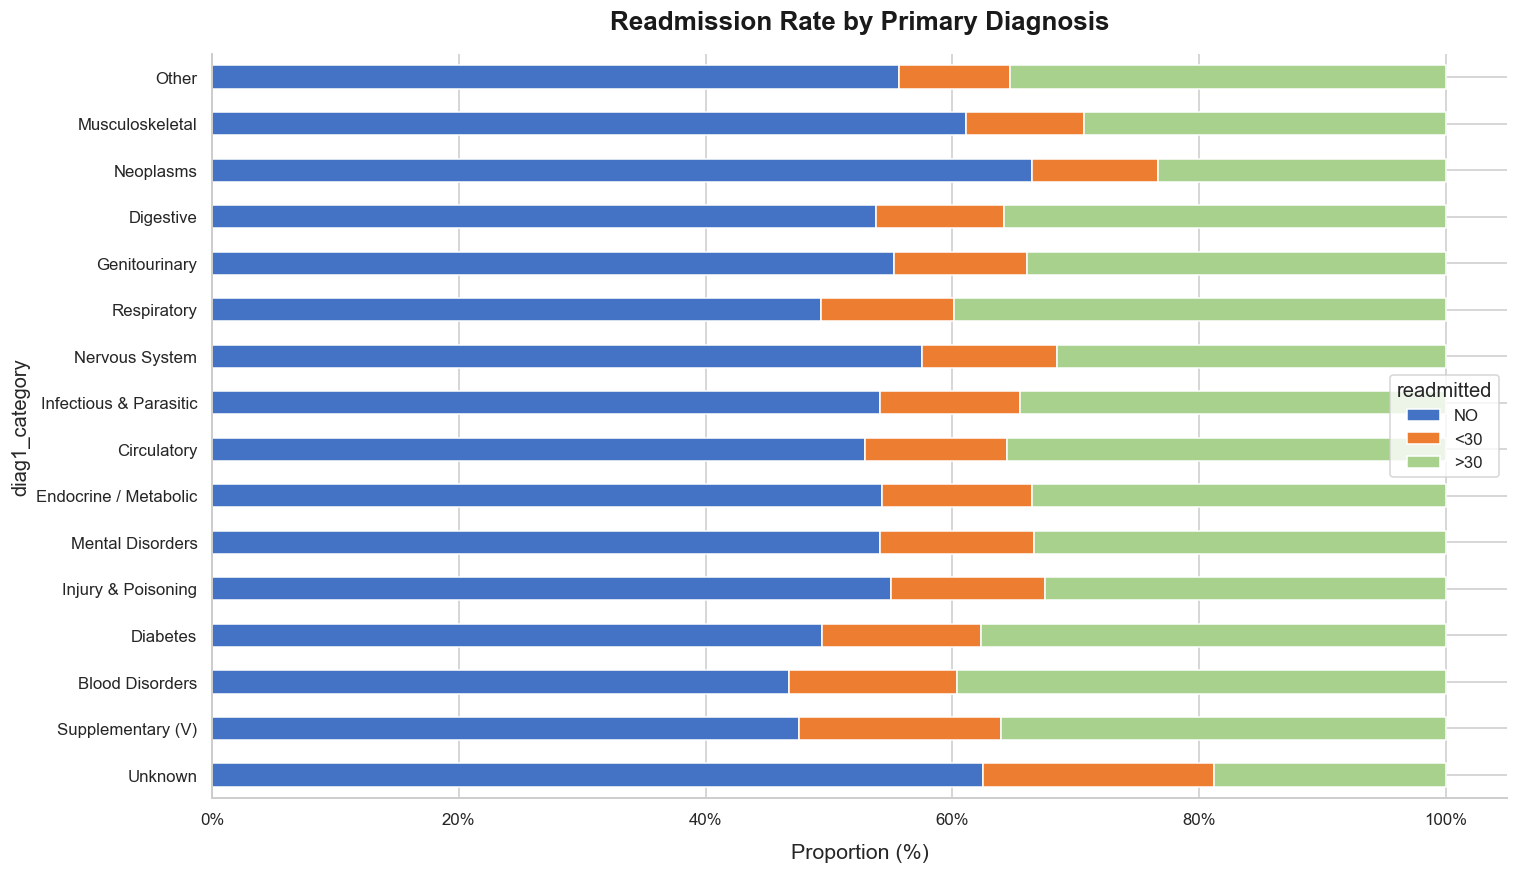

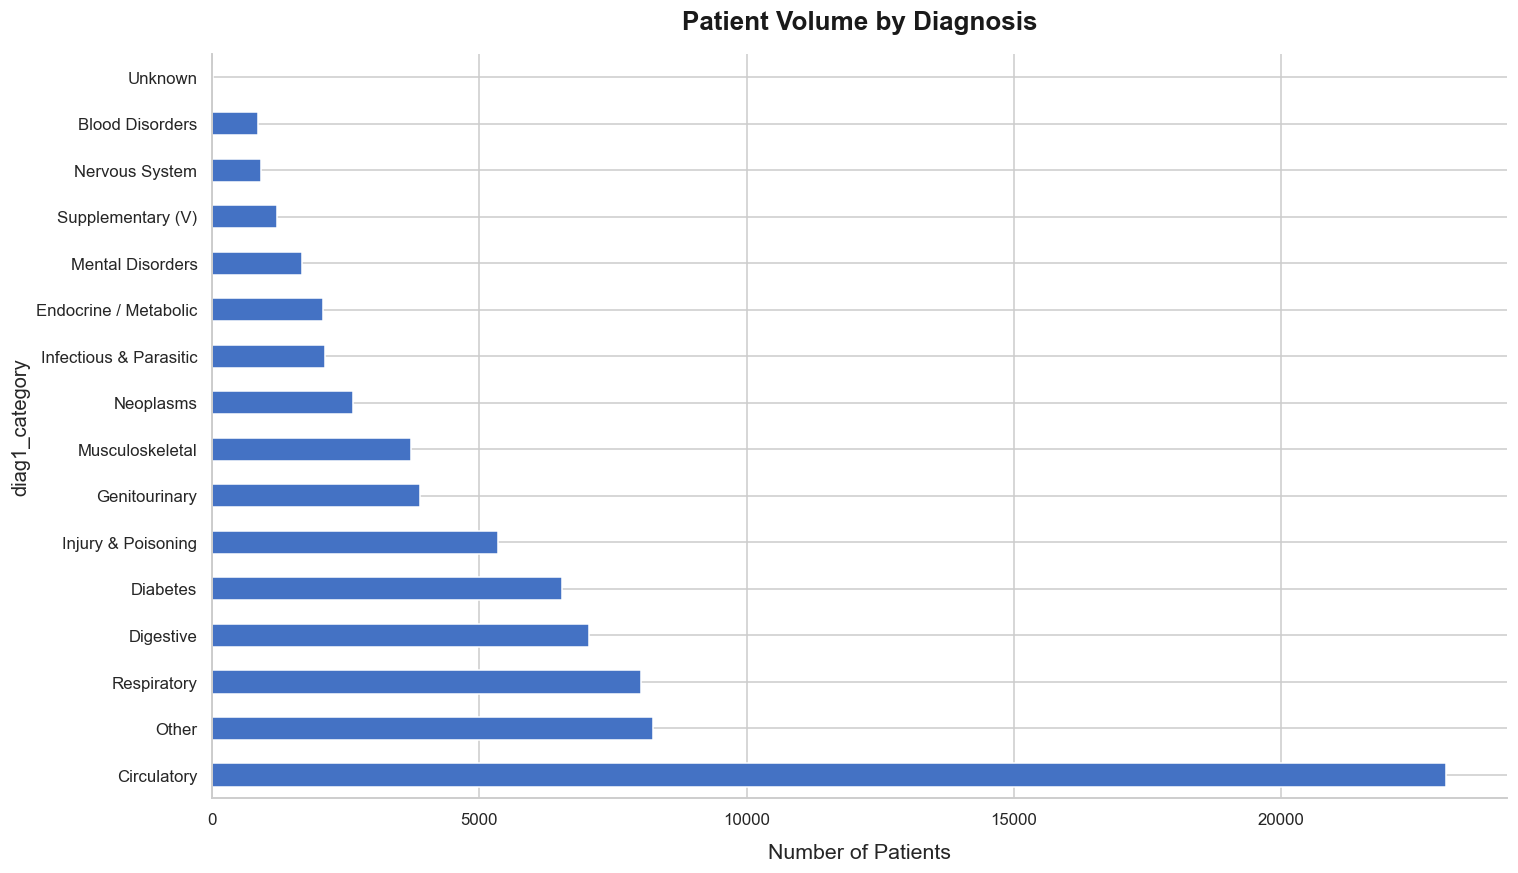

In [32]:
def icd9_category(code):
    code = str(code).strip()
    if code in ('Unknown', 'nan', ''): return 'Unknown'
    if code.startswith('V'): return 'Supplementary (V)'
    if code.startswith('E'): return 'External Causes (E)'
    try: n = float(code)
    except ValueError: return 'Unknown'
    for lo, hi, label in [
        (250,251,'Diabetes'),(1,140,'Infectious & Parasitic'),(140,240,'Neoplasms'),
        (240,280,'Endocrine / Metabolic'),(280,290,'Blood Disorders'),(290,320,'Mental Disorders'),
        (320,390,'Nervous System'),(390,460,'Circulatory'),(460,520,'Respiratory'),
        (520,580,'Digestive'),(580,630,'Genitourinary'),(710,740,'Musculoskeletal'),
        (800,1000,'Injury & Poisoning'),
    ]:
        if lo <= n < hi: return label
    return 'Other'

eda_diag  = train_eda.assign(diag1_category=train_eda['diag_1'].apply(icd9_category))
diag_stats = (eda_diag.groupby('diag1_category')['readmitted']
              .value_counts(normalize=True).unstack(fill_value=0)
              .reindex(columns=['NO', '<30', '>30'], fill_value=0) * 100
              ).sort_values('<30', ascending=False)

for title, data, kind, xlabel, color in [
    ('Readmission Rate by Primary Diagnosis', diag_stats,                              'barh', 'Proportion (%)',      None),
    ('Patient Volume by Diagnosis',           eda_diag['diag1_category'].value_counts(), 'barh', 'Number of Patients', BLUE),
]:
    fig, ax = plt.subplots(figsize=(14, 8))
    if color:
        data.plot(kind=kind, ax=ax, color=color, edgecolor='white')
    else:
        data.plot(kind=kind, stacked=True, ax=ax, color=[BLUE, ORANGE, GREEN], edgecolor='white')
        ax.xaxis.set_major_formatter(mticker.PercentFormatter())
        ax.legend(title='readmitted', fontsize=11)
    ax.set_title(title, fontsize=17, fontweight='bold', pad=16, color=TITLE_COLOR)
    ax.set_xlabel(xlabel, fontsize=14, labelpad=10)
    ax.tick_params(axis='both', labelsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
    print()

#### 2.12. Medication Change Profile

* Engineered two features: n_meds_changed (count of dose adjustments) and n_meds_active (count of active medications) per patient.

* <30 patients had the highest mean medication changes (0.34), suggesting more active dose adjustments at the time of admission.

* Differences across classes are modest, indicating medication change alone is a weak standalone predictor.

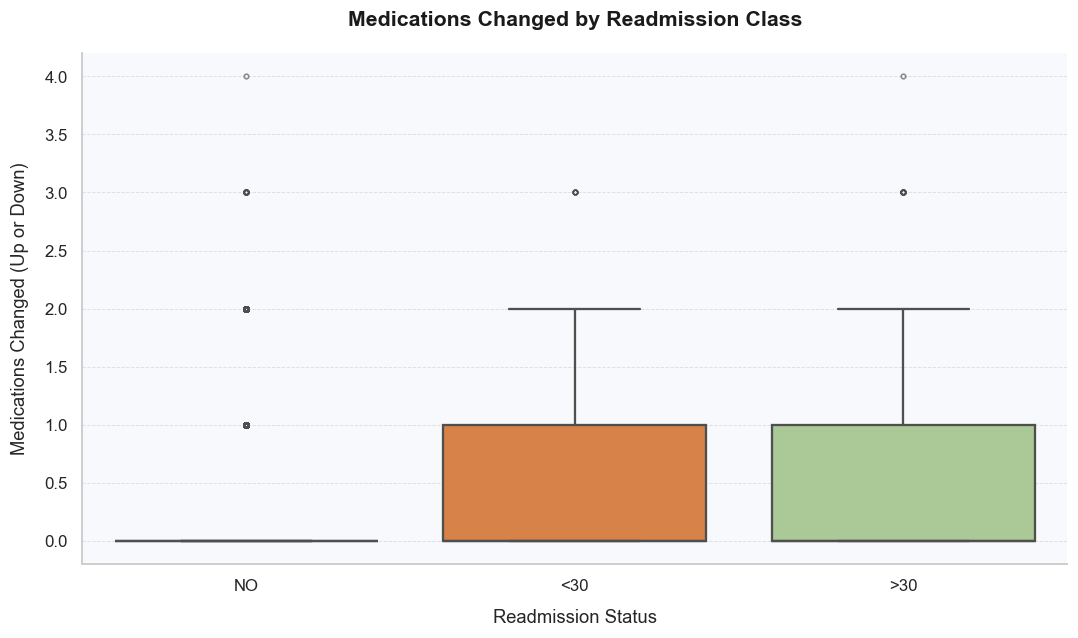

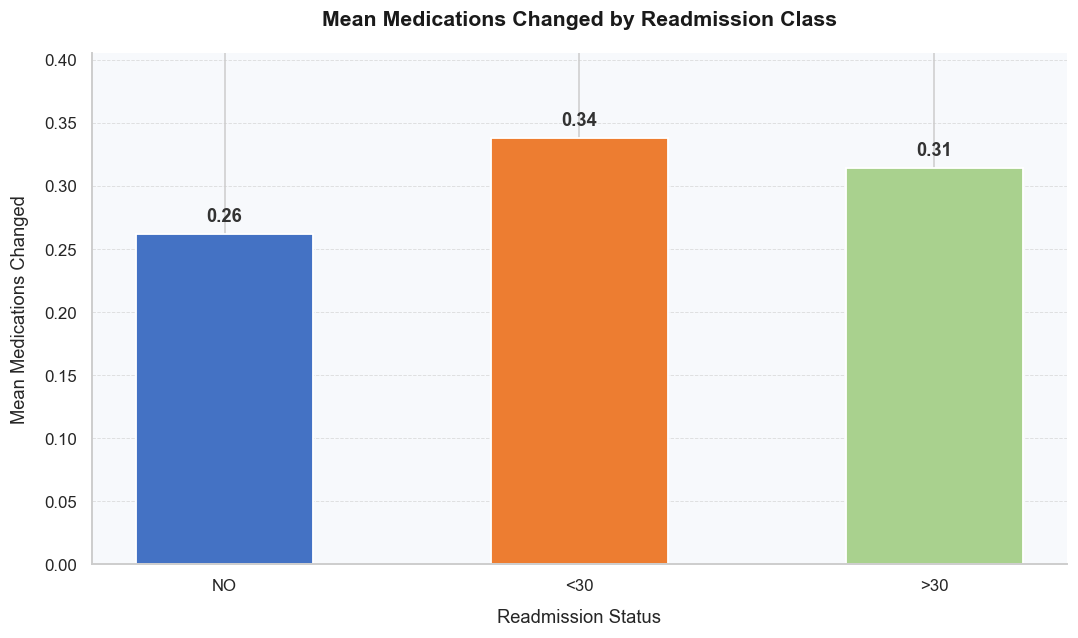

In [33]:
order    = ['NO', '<30', '>30']
med_cols = [c for c in MED_COLS if c in train_eda.columns]
eda_med  = train_eda.assign(
    n_meds_changed = train_eda[med_cols].isin(['Up', 'Down']).sum(axis=1),
    n_meds_active  = train_eda[med_cols].isin(['Steady', 'Up', 'Down']).sum(axis=1),
)

# Box plot
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(AX_BG_COLOR)
sns.boxplot(data=eda_med, x='readmitted', y='n_meds_changed',
            order=order, palette=[BLUE, ORANGE, GREEN],
            linewidth=1.5, flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.set_title('Medications Changed by Readmission Class',
             fontsize=14, fontweight='bold', pad=18, color=TITLE_COLOR)
ax.set_xlabel('Readmission Status', fontsize=12, labelpad=10)
ax.set_ylabel('Medications Changed (Up or Down)', fontsize=12, labelpad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Mean bar chart
means = eda_med.groupby('readmitted')['n_meds_changed'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor(AX_BG_COLOR)
bars = ax.bar(order, means.values, color=[BLUE, ORANGE, GREEN],
              edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + means.max() * 0.02,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('Mean Medications Changed by Readmission Class',
             fontsize=14, fontweight='bold', pad=18, color=TITLE_COLOR)
ax.set_xlabel('Readmission Status', fontsize=12, labelpad=10)
ax.set_ylabel('Mean Medications Changed', fontsize=12, labelpad=10)
ax.set_ylim(0, means.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#### 2.13. Charlson Comorbidity Index (CCI)

* Derived the Charlson Comorbidity Index (CCI) from diag_1, diag_2, diag_3 using ICD-9 weighted scoring across 17 comorbidity conditions.

* <30 patients have the highest mean CCI (1.36) vs NO (1.18), confirming greater disease burden in early readmissions.

Mean CCI by readmission class:
readmitted
<30    1.353
>30    1.227
NO     1.184
Name: cci_score, dtype: float64


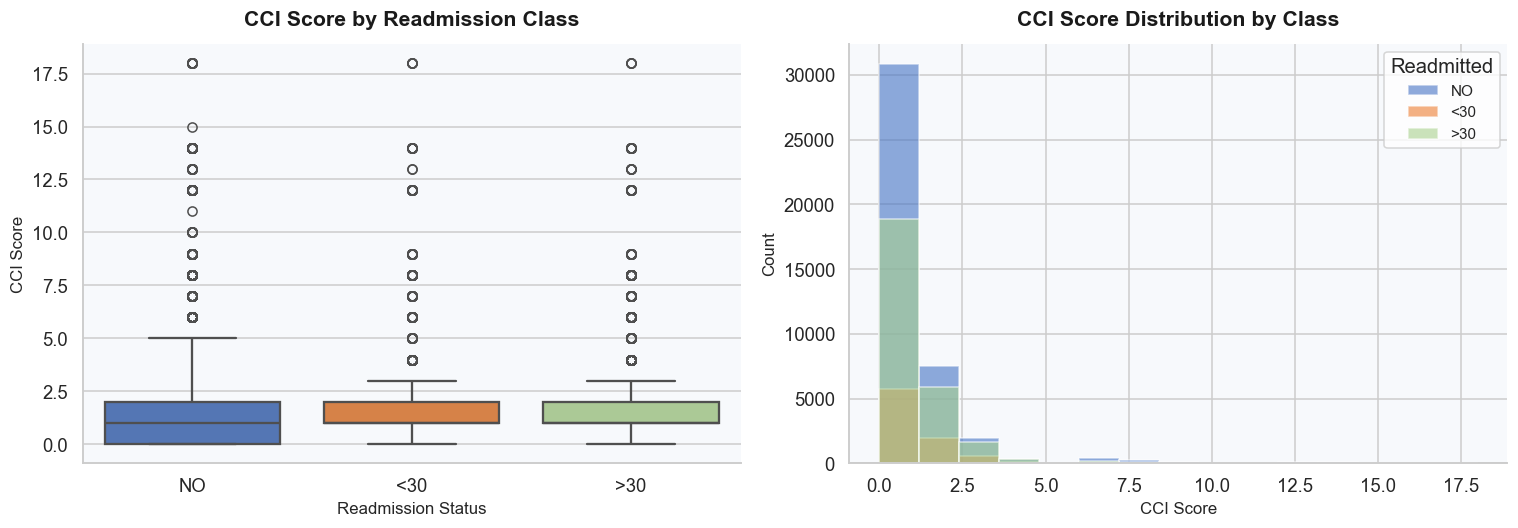

In [34]:
# CCI function 
def compute_cci(row):
    score = 0
    for col in ['diag_1', 'diag_2', 'diag_3']:
        code = str(row.get(col, '') or '').strip()
        if not code or code in ('nan', 'Unknown', ''):
            continue
        try: n = float(code)
        except ValueError: continue
        if 410 <= n <= 411:    score += 1
        if n == 428:           score += 1
        if 443 <= n <= 443.9:  score += 1
        if 430 <= n <= 438:    score += 1
        if n == 290:           score += 1
        if 490 <= n <= 496:    score += 1
        if 710 <= n <= 710.9:  score += 1
        if 531 <= n <= 534.9:  score += 1
        if 571 <= n <= 571.9:  score += 1
        if 250 <= n <= 250.3:  score += 1
        if 342 <= n <= 344.9:  score += 1
        if 582 <= n <= 586:    score += 2
        if 250.4 <= n <= 250.9: score += 1
        if 140 <= n <= 172.9:  score += 2
        if 572 <= n <= 572.9:  score += 3
        if 196 <= n <= 199.9:  score += 6
        if n == 42:            score += 6
    return score

train_eda['cci_score'] = train_eda.apply(compute_cci, axis=1)

print("Mean CCI by readmission class:")
print(train_eda.groupby('readmitted')['cci_score'].mean().round(3))

order = ['NO', '<30', '>30']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train_eda, x='readmitted', y='cci_score',
            order=order, palette=[BLUE, ORANGE, GREEN],
            linewidth=1.5, ax=axes[0])
axes[0].set_title('CCI Score by Readmission Class',
                  fontsize=14, fontweight='bold', pad=12, color=TITLE_COLOR)
axes[0].set_xlabel('Readmission Status', fontsize=11)
axes[0].set_ylabel('CCI Score', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_facecolor(AX_BG_COLOR)

for cls, color in zip(order, [BLUE, ORANGE, GREEN]):
    subset = train_eda[train_eda['readmitted'] == cls]['cci_score']
    axes[1].hist(subset, bins=15, alpha=0.6, color=color, label=cls, edgecolor='white')
axes[1].set_title('CCI Score Distribution by Class',
                  fontsize=14, fontweight='bold', pad=12, color=TITLE_COLOR)
axes[1].set_xlabel('CCI Score', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].legend(title='Readmitted', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_facecolor(AX_BG_COLOR)

plt.tight_layout()
plt.show()

#### 2.14. Repeat Hospitalisation Risk

* Grouped patients by total encounter frequency (1 to 5+) and plotted readmission rates per group

* Clear escalation pattern: NO readmission drops from 78% (1 visit) to 10% (5+ visits)

* '> 30' climbs from 18% to 62%, confirming repeat hospitalisation as a strong risk signal

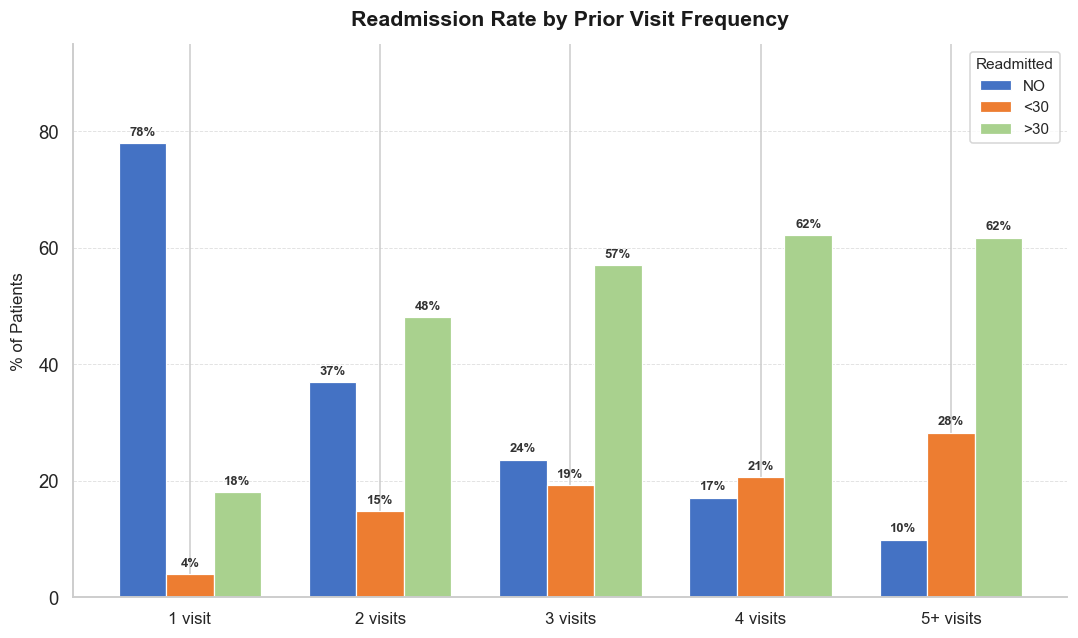

In [35]:
# Map total visit count from full dataset onto training set
visit_counts = pd.read_csv(DATA_PATH)['patient_nbr'].value_counts().rename('visit_count')
train_eda['visit_count'] = train_eda['patient_nbr'].map(visit_counts)
train_eda['visit_group'] = train_eda['visit_count'].clip(upper=5).map(
    lambda x: str(x) if x < 5 else '5+'
)

order  = ['1', '2', '3', '4', '5+']
colors = {'NO': BLUE, '<30': ORANGE, '>30': GREEN}
ct_pct = (train_eda.groupby('visit_group')['readmitted']
                   .value_counts(normalize=True)
                   .unstack()
                   .reindex(order) * 100)[['NO', '<30', '>30']]

x      = range(len(order))
width  = 0.25
fig, ax = plt.subplots(figsize=(10, 6))

for i, (cls, color) in enumerate(colors.items()):
    offsets = [xi + (i - 1) * width for xi in x]
    bars = ax.bar(offsets, ct_pct[cls], width=width, color=color,
                  label=cls, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, ct_pct[cls]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color=DARK_GREY)

ax.set_xticks(list(x))
ax.set_xticklabels([f'{g} visit{"s" if g != "1" else ""}' for g in order], fontsize=11)
ax.set_ylabel('% of Patients', fontsize=11, labelpad=8)
ax.set_title('Readmission Rate by Prior Visit Frequency',
             fontsize=14, fontweight='bold', pad=12, color=TITLE_COLOR)
ax.set_ylim(0, 95)
ax.legend(title='Readmitted', fontsize=10, title_fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#### 2.15. Statistical Hypothesis Testing

* Applied Kruskal-Wallis (numerical) and Chi-Squared (categorical) tests to assess each feature's statistical significance against the readmission target.

* All features are significant (p < 0.001), with number_inpatient and discharge_disposition_id being the strongest signals.

* A1Cresult and max_glu_serum are the weakest — likely due to ~80% missing values.

In [36]:
groups = [train_eda[train_eda['readmitted'] == c] for c in ['NO', '<30', '>30']]

# Kruskal-Wallis for numerical features 
kw_rows = []
for col in NUM_COLS:
    g = [grp[col].dropna().values for grp in groups]
    h, p = kruskal(*g)
    kw_rows.append({'Feature': col, 'H-statistic': round(h, 1), 'p-value': p,
                    'Significant': '***' if p < 0.001 else ('**' if p < 0.01 else '*')})
kw_df = pd.DataFrame(kw_rows).sort_values('H-statistic', ascending=False)

# Chi-squared for categorical features
chi_rows = []
for col in CAT_COLS:
    ct = pd.crosstab(train_eda[col], train_eda['readmitted'])
    chi2_stat, p, dof, _ = chi2_contingency(ct)
    chi_rows.append({'Feature': col, 'Chi2-statistic': round(chi2_stat, 1), 'DoF': dof, 'p-value': p,
                     'Significant': '***' if p < 0.001 else ('**' if p < 0.01 else '*')})
chi_df = pd.DataFrame(chi_rows).sort_values('Chi2-statistic', ascending=False)

print("Kruskal-Wallis — Numerical Features (sorted by H-statistic)")
print(kw_df.to_string(index=False))
print()
print("Chi-Squared — Categorical Features (sorted by Chi2-statistic)")
print(chi_df.to_string(index=False))

Kruskal-Wallis — Numerical Features (sorted by H-statistic)
           Feature  H-statistic       p-value Significant
  number_inpatient       4456.5  0.000000e+00         ***
  number_emergency       1226.8 4.095187e-267         ***
 number_outpatient       1010.8 3.283143e-220         ***
  number_diagnoses        948.2 1.291900e-206         ***
   num_medications        415.3  6.686343e-91         ***
  time_in_hospital        336.0  1.083189e-73         ***
    num_procedures        192.2  1.874571e-42         ***
num_lab_procedures        105.0  1.550959e-23         ***

Chi-Squared — Categorical Features (sorted by Chi2-statistic)
                 Feature  Chi2-statistic  DoF       p-value Significant
discharge_disposition_id          2805.8   48  0.000000e+00         ***
       medical_specialty          1062.9  140 1.181726e-141         ***
     admission_source_id           867.5   32 1.190482e-161         ***
              payer_code           416.4   34  2.432759e-67        

#### 2.16. UMAP — Dimensionality Reduction

* Projected 1,500 patients to 2D using UMAP after label-encoding all features.

* Classes are not linearly separable — <30 and >30 overlap heavily, indicating the model's difficulty in distinguishing early readmission.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


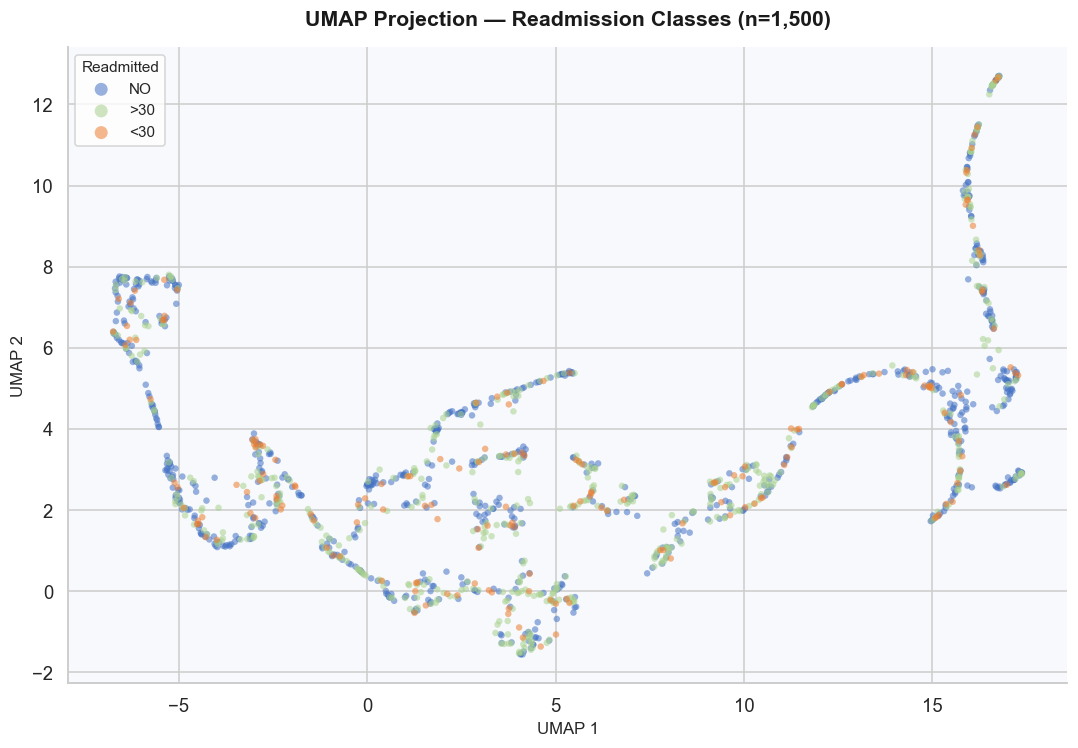

In [37]:
sample = train_eda.sample(1500, random_state=RANDOM_STATE)
X_s = sample.drop(columns='readmitted').copy()
y_s = sample['readmitted']

for col in X_s.select_dtypes(include=['object', 'category']).columns:
    X_s[col] = LabelEncoder().fit_transform(X_s[col].astype(str))
X_s = X_s.fillna(0)

emb = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                n_neighbors=30, min_dist=0.1).fit_transform(X_s)

# Plot
palette = {'NO': BLUE, '>30': GREEN, '<30': ORANGE}
fig, ax  = plt.subplots(figsize=(10, 7))
for cls, color in palette.items():
    mask = y_s == cls
    ax.scatter(emb[mask, 0], emb[mask, 1], c=color, label=cls,
               s=18, alpha=0.55, edgecolors='none')

ax.set_title('UMAP Projection — Readmission Classes (n=1,500)',
             fontsize=14, fontweight='bold', pad=14, color=TITLE_COLOR)
ax.set_xlabel('UMAP 1', fontsize=11); ax.set_ylabel('UMAP 2', fontsize=11)
ax.legend(title='Readmitted', fontsize=10, title_fontsize=10, markerscale=2)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor(AX_BG_COLOR)
plt.tight_layout()
plt.show()

## 3. Machine Learning Training with AutoGluon

* AutoGluon automates feature engineering, model selection, ensembling, and hyperparameter tuning.

* Training is performed on `train_df` (the 95% split). Evaluation uses `X_test / y_test` (the 20% hold-out set).

#### 3.1. Train AutoGluon TabularPredictor

* Engineered three features from existing columns: n_meds_changed, n_meds_active (from medication columns), and cci_score.

* Applied SMOTENC to the training set only (no leakage) to balance the class distribution across NO, <30, and >30.

* Trained an AutoGluon TabularPredictor using LightGBM, XGBoost, and CatBoost (GBM-only), optimising for roc_auc_ovo_macro with a 600-second time limit.

* No bagging or stacking used — equivalent to medium_quality preset but restricted to GBM models for memory efficiency.

In [38]:
def add_engineered_features(df):
    med_cols = [c for c in MED_COLS if c in df.columns]
    df = df.copy()
    df['n_meds_changed'] = df[med_cols].isin(['Up', 'Down']).sum(axis=1)
    df['n_meds_active']  = df[med_cols].isin(['Steady', 'Up', 'Down']).sum(axis=1)
    df['cci_score']      = df.apply(compute_cci, axis=1)
    return df

X_test_fe = add_engineered_features(X_test)
print(f"Features added. test shape: {X_test_fe.shape}")
print(f"CCI score sample: {X_test_fe['cci_score'].describe().round(2).to_dict()}")

Features added. test shape: (19341, 49)
CCI score sample: {'count': 19341.0, 'mean': 1.22, 'std': 1.48, 'min': 0.0, '25%': 0.0, '50%': 1.0, '75%': 2.0, 'max': 18.0}


In [39]:
# Clear any previous model artefacts
if os.path.exists(MODEL_PATH):
    shutil.rmtree(MODEL_PATH)

# Use only train_p patients for SMOTE — test_p must not leak into training
train_only_fe = add_engineered_features(pd.concat([X_train, y_train], axis=1))

X_sm = train_only_fe.drop(columns='readmitted').copy()
for col in X_sm.select_dtypes(include='object').columns:
    X_sm[col] = X_sm[col].astype(str)
for col in X_sm.select_dtypes(include='category').columns:
    X_sm[col] = X_sm[col].astype(str)
for col in X_sm.select_dtypes(include='number').columns:
    X_sm[col] = pd.to_numeric(X_sm[col], errors='coerce').fillna(0)

cat_idx = [i for i, c in enumerate(X_sm.columns) if X_sm[c].dtype == object]
sm = SMOTENC(categorical_features=cat_idx, random_state=RANDOM_STATE, k_neighbors=3)
X_res, y_res = sm.fit_resample(X_sm, train_only_fe['readmitted'])

train_df_smote = pd.DataFrame(X_res, columns=X_sm.columns)
train_df_smote['readmitted'] = y_res
print(f"After SMOTE: {train_df_smote['readmitted'].value_counts().to_dict()}")

predictor = TabularPredictor(
    label='readmitted',
    eval_metric='roc_auc_ovo_macro',
    path=MODEL_PATH
).fit(
    train_data=train_df_smote,
    hyperparameters=GBM_ONLY,
    time_limit=600,
    ag_args_fit={'ag.max_memory_usage_ratio': 2.0},
    num_bag_folds=0,
    num_stack_levels=0
)

Verbosity: 2 (Standard Logging)


After SMOTE: {'NO': 41635, '>30': 41635, '<30': 41635}


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.4
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 21.6.0: Mon Jun 24 00:59:34 PDT 2024; root:xnu-8020.240.18.709.2~1/RELEASE_ARM64_T8101
CPU Count:          8
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
Memory Avail:       2.38 GB / 8.00 GB (29.7%)
Disk Space Avail:   3.25 GB / 228.27 GB (1.4%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models

[1000]	valid_set's multi_logloss: 0.739489	valid_set's roc_auc_ovo: 0.833413
[2000]	valid_set's multi_logloss: 0.723857	valid_set's roc_auc_ovo: 0.843478
[3000]	valid_set's multi_logloss: 0.72171	valid_set's roc_auc_ovo: 0.847582
[4000]	valid_set's multi_logloss: 0.722684	valid_set's roc_auc_ovo: 0.851084
[5000]	valid_set's multi_logloss: 0.72794	valid_set's roc_auc_ovo: 0.853245
[6000]	valid_set's multi_logloss: 0.73478	valid_set's roc_auc_ovo: 0.854776
[7000]	valid_set's multi_logloss: 0.741722	valid_set's roc_auc_ovo: 0.856394
[8000]	valid_set's multi_logloss: 0.750889	valid_set's roc_auc_ovo: 0.857555
[9000]	valid_set's multi_logloss: 0.759792	valid_set's roc_auc_ovo: 0.858742
[10000]	valid_set's multi_logloss: 0.7711	valid_set's roc_auc_ovo: 0.859551


	0.8596	 = Validation score   (roc_auc_ovo)
	178.04s	 = Training   runtime
	2.25s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 415.98s of the 415.98s of remaining time.
	Fitting with cpus=8, gpus=0
	Ran out of time, early stopping on iteration 795.
	0.8604	 = Validation score   (roc_auc_ovo)
	415.55s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 0.01s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=8, gpus=0, mem=0.0/1.5 GB
	Ensemble Weights: {'CatBoost': 0.619, 'LightGBM': 0.381}
	0.8747	 = Validation score   (roc_auc_ovo)
	0.14s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 600.23s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 1089.2 rows/s (2499 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Users/sieunpark/Desktop/Questions_SQL/ag_models")


#### 3.2. Model Leaderboard

In [40]:
# Build and save leaderboard ranked by validation performance
test_df = X_test_fe.copy()
test_df['readmitted'] = y_test.values

leaderboard = predictor.leaderboard(data=test_df, silent=False)
leaderboard.to_csv('leaderboard.csv', index=False)

                 model  score_test  score_val  eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0             CatBoost    0.657916   0.860392  roc_auc_ovo        0.216076       0.044839  415.552118                 0.216076                0.044839         415.552118            1       True          2
1  WeightedEnsemble_L2    0.657296   0.874658  roc_auc_ovo       25.175783       2.294372  593.735164                 0.007327                0.002532           0.138987            2       True          3
2             LightGBM    0.634093   0.859553  roc_auc_ovo       24.952380       2.247001  178.044059                24.952380                2.247001         178.044059            1       True          1


#### 3.3. Evaluate Best Model on Hold-Out Test Set
* Evaluated the best model on X_test_fe using accuracy, macro F1, classification report, and confusion matrix.

* <30 showed the weakest recall due to class imbalance, motivating threshold tuning in the next section.

  Best model : WeightedEnsemble_L2
  Accuracy   : 0.5822  (58.22%)
  F1 (macro) : 0.4456
              precision    recall  f1-score   support

         <30       0.24      0.11      0.15      2170
         >30       0.50      0.47      0.48      6723
          NO       0.65      0.75      0.70     10448

    accuracy                           0.58     19341
   macro avg       0.46      0.44      0.45     19341
weighted avg       0.55      0.58      0.56     19341



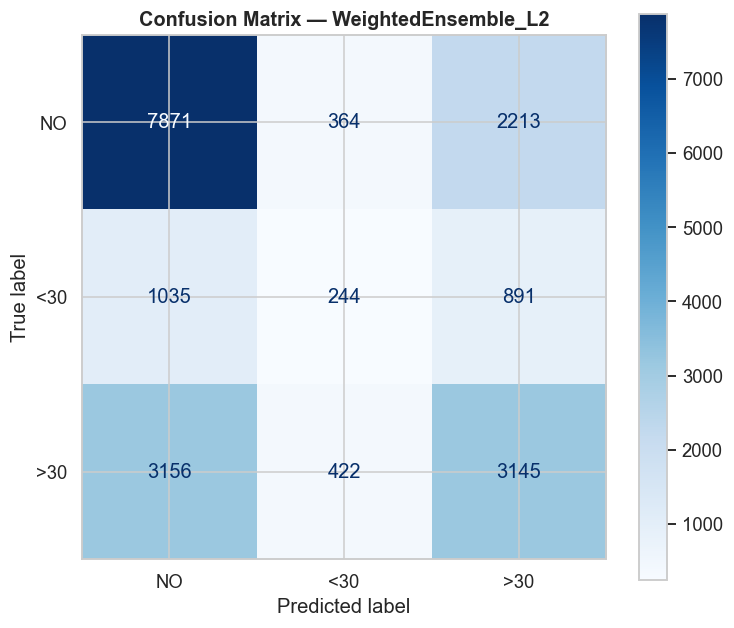

In [41]:
y_pred   = predictor.predict(X_test_fe)
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"  Best model : {predictor.model_best}")
print(f"  Accuracy   : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  F1 (macro) : {f1_macro:.4f}")
print(classification_report(y_test, y_pred))

classes = ['NO', '<30', '>30']
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {predictor.model_best}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.4. Threshold Tuning for `<30` Class

* Swept decision thresholds (0.05–0.54) for the <30 class and selected the value maximising its F1 score.

* Applied the optimal threshold to improve early readmission recall at the cost of a small drop in overall accuracy.

Optimal threshold for <30 : 0.13
  F1 (<30)   : 0.2541
  F1 (macro) : 0.4162


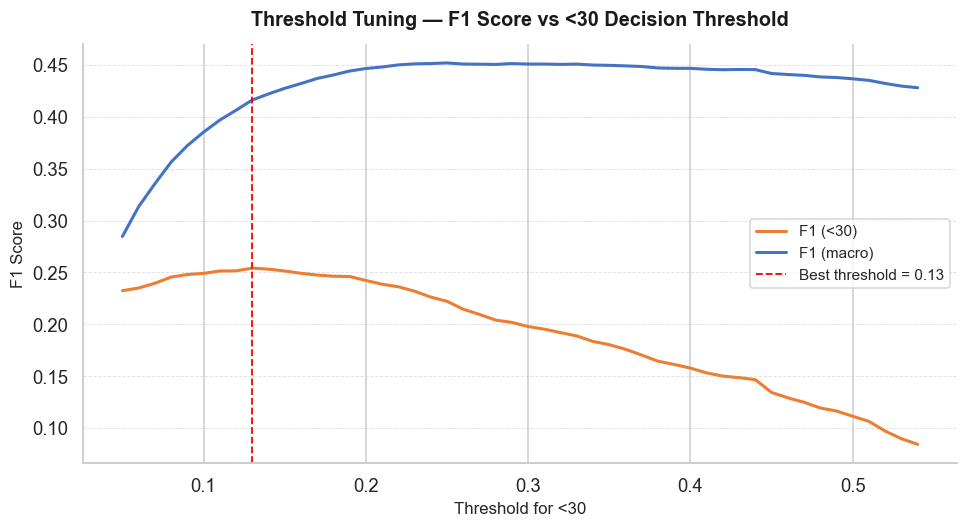


--- After Threshold Tuning ---
  Accuracy   : 0.4812
  F1 (macro) : 0.4162
              precision    recall  f1-score   support

         <30       0.17      0.50      0.25      2170
         >30       0.51      0.27      0.35      6723
          NO       0.68      0.62      0.64     10448

    accuracy                           0.48     19341
   macro avg       0.45      0.46      0.42     19341
weighted avg       0.56      0.48      0.50     19341



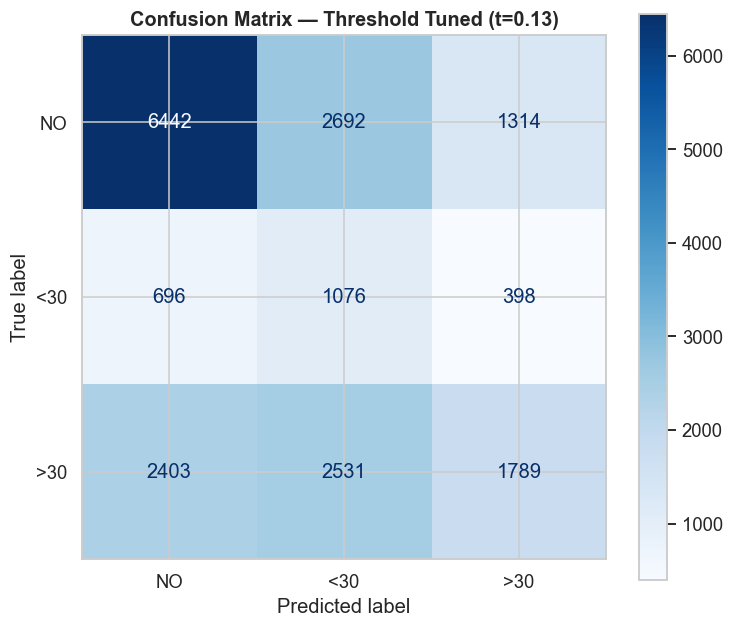

In [42]:
# Get predicted probabilities
proba = predictor.predict_proba(X_test_fe)   # columns: ['<30', '>30', 'NO']

# Sweep thresholds — find best F1 for <30
thresholds = np.arange(0.05, 0.55, 0.01)
rows = []
for t in thresholds:
    y_t = np.where(proba['<30'] >= t, '<30', proba[['NO', '>30']].idxmax(axis=1))
    rows.append({
        'threshold' : round(t, 2),
        'f1_lt30'   : f1_score(y_test, y_t, labels=['<30'], average='macro'),
        'f1_macro'  : f1_score(y_test, y_t, average='macro'),
    })
thresh_df = pd.DataFrame(rows)

# Best threshold = highest F1 for <30
best = thresh_df.loc[thresh_df['f1_lt30'].idxmax()]
best_t = best['threshold']
print(f"Optimal threshold for <30 : {best_t}")
print(f"  F1 (<30)   : {best['f1_lt30']:.4f}")
print(f"  F1 (macro) : {best['f1_macro']:.4f}")

# Plot F1 vs threshold
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['threshold'], thresh_df['f1_lt30'],  color=ORANGE, linewidth=2, label='F1 (<30)')
ax.plot(thresh_df['threshold'], thresh_df['f1_macro'], color=BLUE,   linewidth=2, label='F1 (macro)')
ax.axvline(best_t, color='red', linestyle='--', linewidth=1.2, label=f'Best threshold = {best_t}')
ax.set_xlabel('Threshold for <30', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Threshold Tuning — F1 Score vs <30 Decision Threshold',
             fontsize=13, fontweight='bold', pad=12, color=TITLE_COLOR)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Apply best threshold and show final metrics
y_pred_tuned = np.where(proba['<30'] >= best_t, '<30', proba[['NO', '>30']].idxmax(axis=1))
print("\n--- After Threshold Tuning ---")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  F1 (macro) : {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(classification_report(y_test, y_pred_tuned))

classes = ['NO', '<30', '>30']
cm = confusion_matrix(y_test, y_pred_tuned, labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — Threshold Tuned (t={best_t})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 3.5. SHAP Explainability

* Extracted the LightGBM booster from AutoGluon and computed SHAP values on a 300-patient sample.

* Global beeswarm plots ranked feature impact per class; a local waterfall plot explained an individual NO prediction.

SHAP computed: 300 patients x 44 features x 3 classes


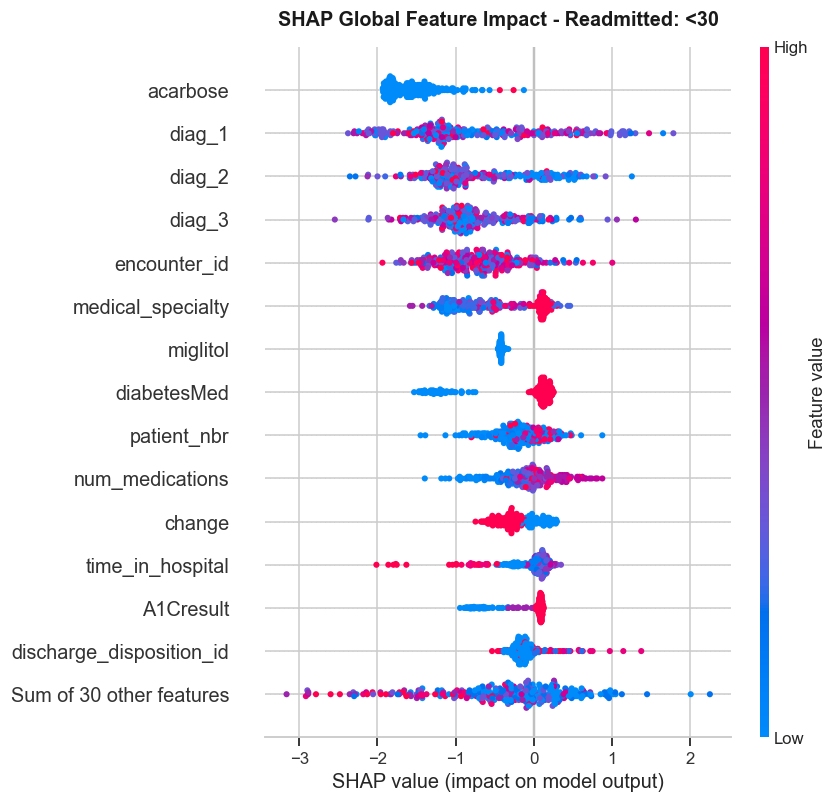

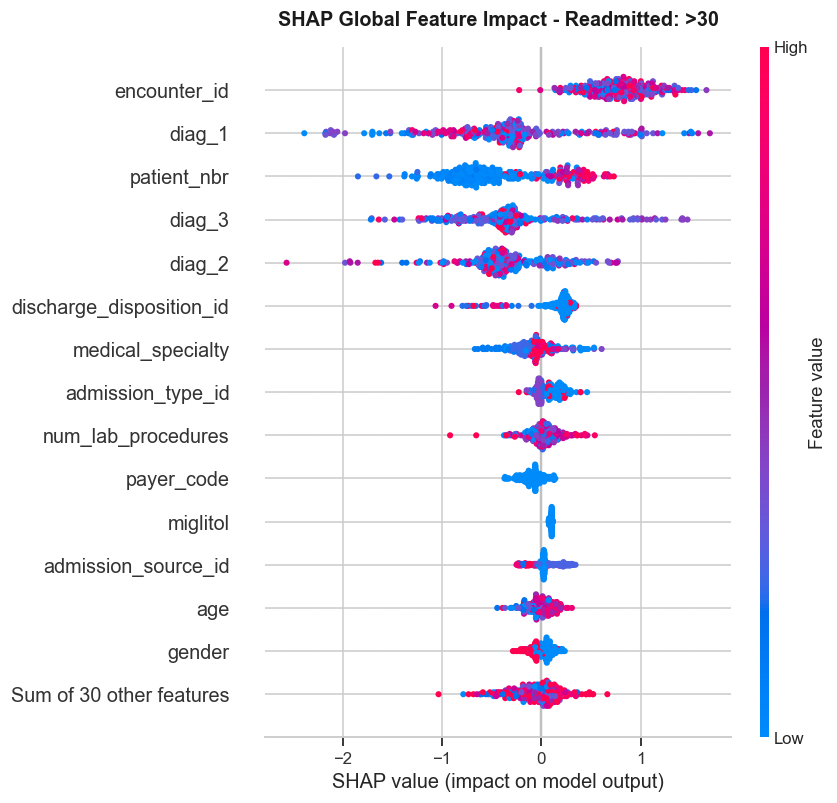

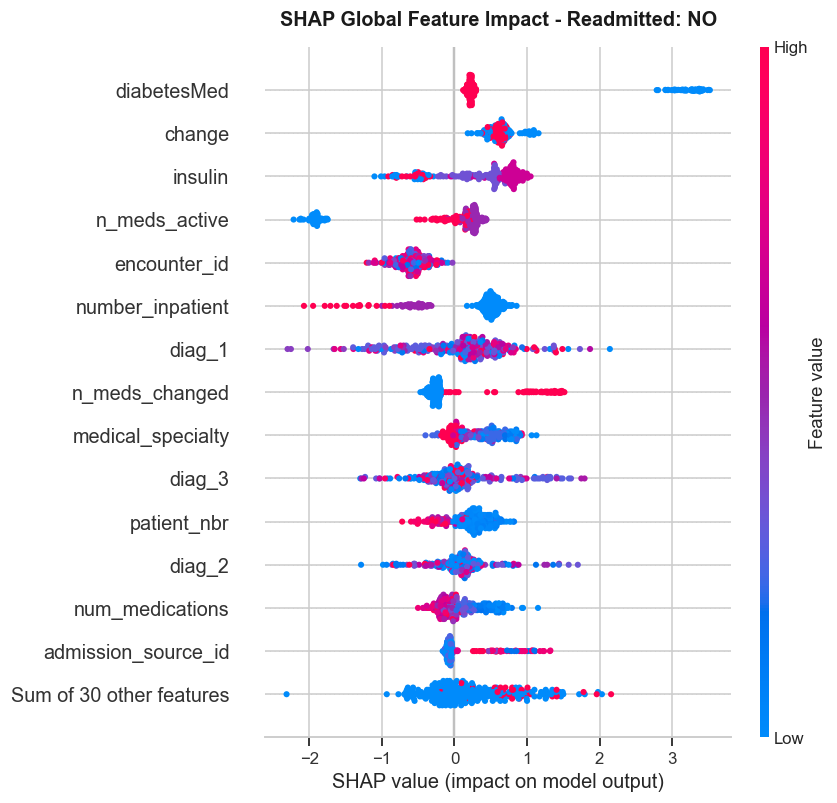

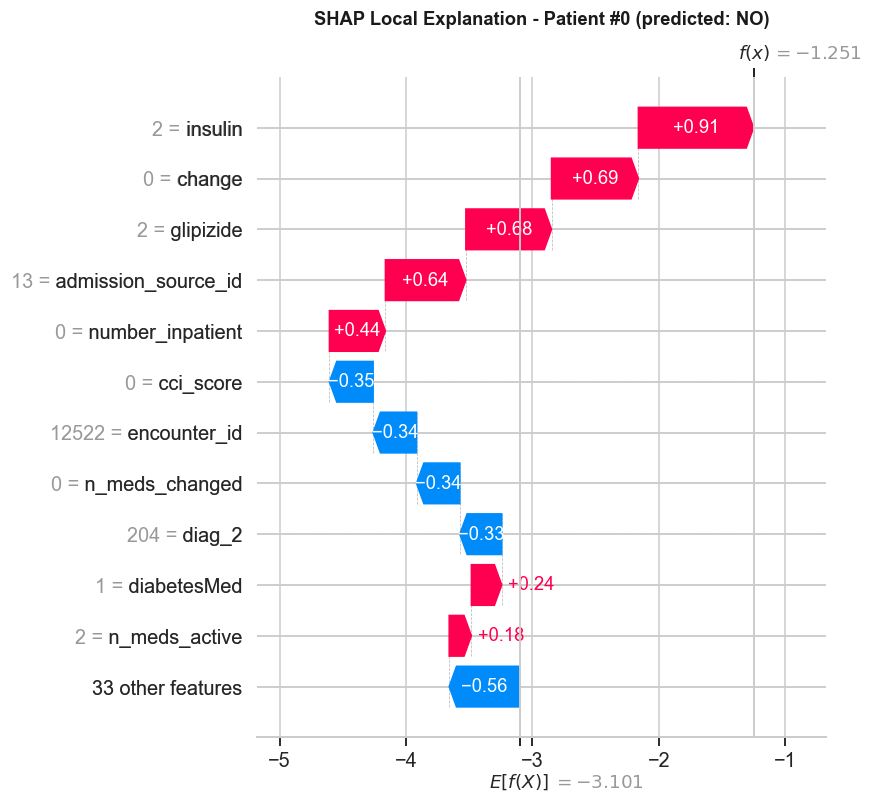

In [43]:
# Extract LightGBM booster and preprocess test set
lgbm_model   = predictor._trainer.load_model('LightGBM')
booster      = lgbm_model.model
class_labels = predictor.class_labels          # ['<30', '>30', 'NO']

X_prep = lgbm_model.preprocess(X_test_fe, is_train=False)
X_num  = X_prep.copy()
for col in X_num.select_dtypes(include=['object', 'category']).columns:
    X_num[col] = LabelEncoder().fit_transform(X_num[col].astype(str))

sample_arr = X_num.head(300).values.astype(float)
feat_names = list(X_num.columns)

# Compute SHAP values (n_samples, n_features, n_classes)
explainer = shap.TreeExplainer(booster)
sv = explainer.shap_values(sample_arr)
ev = explainer.expected_value
print(f"SHAP computed: {sv.shape[0]} patients x {sv.shape[1]} features x {sv.shape[2]} classes")

# Global: beeswarm per class
for ci, cls in enumerate(class_labels):
    exp = shap.Explanation(values=sv[:, :, ci], base_values=ev[ci],
                           data=sample_arr, feature_names=feat_names)
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(exp, max_display=15, show=False, color_bar=True)
    plt.title(f'SHAP Global Feature Impact - Readmitted: {cls}',
              fontsize=13, fontweight='bold', pad=14, color=TITLE_COLOR)
    plt.tight_layout()
    plt.show()

# Local: waterfall for one patient predicted as NO
y_pred_sample = predictor.predict(X_test_fe.head(300))
ci = class_labels.index('NO')
i  = next(idx for idx, p in enumerate(y_pred_sample) if p == 'NO')

exp_i = shap.Explanation(values=sv[i, :, ci], base_values=ev[ci],
                         data=sample_arr[i], feature_names=feat_names)
fig, ax = plt.subplots(figsize=(10, 6))
shap.plots.waterfall(exp_i, max_display=12, show=False)
plt.title(f'SHAP Local Explanation - Patient #{i} (predicted: NO)',
          fontsize=12, fontweight='bold', pad=12, color=TITLE_COLOR)
plt.tight_layout()
plt.show()